# 호텔 예약 취소 예측 MLP — 주석·해설본

최신 `Deep_Learning_PRJ(1).zip`의 `hotel_deep.ipynb`를 바탕으로 작성했다.
**기존 코드의 실행 로직, 변수명, 셀 순서, 출력, 실행 번호는 유지했다.**
추가한 것은 코드 주석과 설명용 Markdown 셀뿐이며 학습·예측·저장 셀은 실행하지 않았다.
원본 ZIP도 변경하지 않았다. 원본 코드 셀의 번호는 `원본 셀 01`처럼 1부터 표시한다.
이는 Jupyter의 `In [실행 번호]`가 아니라 원본 파일에서의 셀 위치이다.

## 먼저 확인할 실행 주의사항

- 이 문서는 **실험 이력에 해설을 붙인 노트북**이지 새 커널에서 전체 실행을 보장하도록 수정한 실행 스크립트가 아니다.
- `Run All`을 누르면 기본 학습·탐색·최종 재학습과 파일 덮어쓰기가 발생할 수 있다. 저장 결과 확인만 필요하면 해당 읽기/시각화 셀만 준비해서 실행한다.
- 원본의 baseline 로그는 4 Epoch만 남았고 평가 출력은 예전 59 Epoch 결과이다. 저장 출력은 과거 기록이지 현재 커널 변수의 상태가 아니다.
- 원본 셀 58의 `cm_default`, `cm_optimized`, 원본 셀 66의 두 Test 확률 변수는 정의 코드가 빠져 있다. 원본 셀 67도 먼저 로드된 `mlp_preprocessor`에 의존한다. 각 위치에 주석을 추가했다.
- 과거 RF 비교는 23,713건, MLP는 23,712건으로 평가 대상이 다르다. 최신 공통 RF 결과로 갱신하기 전까지 최종 공정 비교로 사용하지 않는다.
- 확률 0.00206%가 화면에서 0.0%로 표시되는 것은 반올림 문제이다. 가까운 실제 예약으로 기본값을 바꾼 것은 **입력 변경**이지 확률 보정이나 학습 오류 수정이 아니다.

## 전체 흐름

데이터 정제 → 분할·스케일링 → 기본 MLP → 광범위/집중 탐색 → 시드 반복 검증 →
선정 설정의 Validation 학습 → 임계값 선택 → 전체 Train 재학습 → Test 평가 → RF 비교 → 입력 진단.

## 데이터·모델 역할

| 구분 | 역할 | 주의 |
|---|---|---|
| `X_subtrain` | 모델 탐색·검증용 MLP 가중치 학습 | 해당 전처리기도 Sub-train에만 fit |
| `X_val` | 설정·Epoch·임계값 선택 | Test 성능으로 표기하지 않음 |
| `X_train` | Sub-train과 Validation을 합친 최종 재학습 입력 | 최종 모델을 과거 Validation에 평가하면 학습 자료가 섞임 |
| `X_test` | 사전에 고정한 모델·임계값의 최종 평가 | 설정을 Test 결과에 맞춰 재선택하지 않음 |
| `model` / `best_mlp` | 기본 128-64-32 MLP | 파일 덮어쓰기 이력 확인 |
| `selected_mlp_val` | 선정 설정의 검증용 256-128-64 MLP | 107 Epoch 고정, 콜백 없음 |
| `final_mlp` / `loaded_final_mlp` / `mlp_model` | 전체 Train 학습 및 저장된 최종 MLP를 가리키는 변수 | 각 로드 시점과 전처리기 버전을 확인 |

## 주요 파일 찾기 — 딥러닝 프로젝트 루트 기준

| 자료 | 경로 | 용도 |
|---|---|---|
| 탐색 전체 | `model_dl/combined/all_unique_results.csv` | 289개 설정 요약 |
| 반복 요약 | `model_dl/stability/stability_summary.csv` | 10개 설정의 평균·표준편차 |
| 검증 학습 곡선 | `model_dl/validation/mlp_validation_history.csv` | Train/Validation 107 Epoch |
| 검증 확률 | `model_dl/validation/mlp_validation_predictions.csv` | 임계값 탐색·확률 진단 |
| 검증용 모델 | `model_dl/validation/selected_mlp_validation_epoch107.keras` | 전체 Train 학습 전 모델 |
| 최종 모델 | `model_dl/final/final_mlp.keras` | 서비스 추론 |
| 최종 전처리기 | `model_dl/final/final_mlp_preprocessor.joblib` | 최종 모델 입력 변환 |
| 최종 학습 곡선 | `model_dl/final/final_mlp_history.csv` | Train만 있는 기록 |
| Test 확률·지표 | `model_dl/final/final_mlp_test_predictions.csv`, `final_mlp_test_metrics.csv`(같은 폴더) | ROC Curve·지표·혼동행렬 |
| 공통 분할 | `model_dl/comparison/common_data_split.joblib` | 입력·정답·인덱스 복원 |
| 공통 RF 결과 | `../ML_PRJ/model_dl/comparison/rf_common_test_predictions.csv` | 원본 셀의 기존 RF 경로와 구분 |

`.keras`는 신경망, `.joblib`은 여기서 전처리기·분할 데이터 등에 사용하며 `.json`은 설정/입력값, `.csv`는 표 형식 기록이다.
파일 이름만 맞는다고 같은 실험 버전인 것은 아니다. 모델·전처리기·분할·평가 결과를 함께 관리한다.


## 00. 실행 환경 확인

라이브러리와 데이터 경로를 확인하는 준비 단계이다.


In [23]:
# ── 원본 셀 01 | 커널 실행 확인 ──
# print가 출력되는지 확인하는 테스트 셀이다. 모델·데이터·파일은 변경하지 않는다.

print('test')

test


### 데이터 전처리

## 01. 데이터 로드·정제

기존 RF와 비교하려면 정제 조건과 대상 예약이 같은지 확인해야 한다. 이 주석본은 전처리 규칙을 변경하지 않는다.


In [15]:
# ── 원본 셀 03 | 라이브러리와 주요 도구 준비 ──
# pandas/NumPy는 표·배열 처리, Matplotlib/seaborn은 시각화, TensorFlow/Keras는 MLP를 담당한다.
# ColumnTransformer는 열 종류별 변환을 묶고 Pipeline은 변환 단계를 순서대로 연결한다.
# joblib은 전처리기·분할 데이터 저장에, .keras 형식은 신경망 모델 저장에 사용한다.
# 이 셀은 도구를 가져올 뿐 데이터 읽기나 모델 학습을 수행하지 않는다.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

import os
import random
import joblib
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [16]:
# ── 원본 셀 04 | 원본 CSV 읽기 ──
# 프로젝트 루트를 현재 작업 폴더로 가정한다. 상대경로는 노트북 파일명이 아닌 실행 작업 폴더 기준이다.
# head()는 앞부분을 보여줄 뿐 전처리나 학습을 하지 않는다.

df = pd.read_csv('./dataset/hotel_booking.csv', encoding='utf-8')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [17]:
# ── 원본 셀 05 | 전처리용 복사본 생성 ──
# df 원본을 보존하고 df2에서 가공한다.
# 뒤 전처리 셀은 여러 열을 삭제하므로 다시 실행하려면 이 셀부터 복사본을 복원해야 한다.

df2 = df.copy()

In [18]:
# ── 원본 셀 06 | 결측·이상치 처리와 파생변수 생성 ──
# 입력: 원본을 복사한 df2. 출력: 예약 취소 예측에 사용할 정제된 df2.
# 총 인원·숙박일·아이 동반·에이전트/회사 이용 여부 등으로 원본 정보를 재구성한다.
# has_weekend_stay는 만들지만 마지막에는 삭제하므로 실제 모델 입력에는 포함되지 않는다.
# 주의: 국가 상위 10개는 분할 전 전체 데이터에서 선택한다. 엄격한 평가에서는 Train으로 목록을 정하는 것이 바람직하나 여기서는 원본 코드를 유지했다.
# 개인정보/예약 결과 관련 열 제거와 그 밖의 실험상 열 제외를 모두 같은 사유의 제거로 설명하지 않는다.

# children의 결측치는 0으로 처리 후 정수형으로 바꿈
# [해설] fillna(0)는 결측 아동 수를 0으로 가정한다. 결측이 실제 0이라는 사실을 확인한 것은 아니다.
df2["children"] = df2["children"].fillna(0).astype(int)

# 투숙객 0명 값 제거
df2 = df2[
    (df2["adults"] + df2["children"] + df2["babies"]) > 0
]

print("제거 후 데이터 크기:", df2.shape)

# children / babies 극단값 제거
df2 = df2[
    (df2["children"] < 5) &
    (df2["babies"] < 5)
]

print("제거 후 데이터 크기:", df2.shape)

# adr 이상치 처리
df2 = df2[
    (df2["adr"] >= 0)
    & (df2["adr"] <= 1000)
]

# 파생변수 : 성인+아동+영아 -> 투숙객 수 
df2["total_guests"] = (
    df2["adults"]
    + df2["children"]
    + df2["babies"]
)

# 파생변수 : 아이 동반
df2["has_children"] = (
    (df2["children"] + df2["babies"]) > 0
).astype(int)

# 원본 제거
df2 = df2.drop(columns=["adults", "children", "babies"])

# agent / company는 ID 대신 이용 여부 변수 생성
df2["has_agent"] = df2["agent"].notna().astype(int)
df2["has_company"] = df2["company"].notna().astype(int)

# 원본 제거
df2 = df2.drop(columns=["agent", "company"])

# 총 숙박일수
df2["total_nights"] = (
    df2["stays_in_weekend_nights"]
    + df2["stays_in_week_nights"]
)

# 주말 포함 여부
df2["has_weekend_stay"] = (
    df2["stays_in_weekend_nights"] > 0
).astype(int)

# 숙박일수 0 제거 및 관련 컬럼 삭제
df2 = df2[df2["total_nights"] > 0]
print("0박 예약 제거 후 데이터 크기:", df2.shape)

df2 = df2.drop(
    columns=[
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "has_weekend_stay"
    ]
)

print("남은 0박 예약:", (df2["total_nights"] == 0).sum())

# 파생컬럼 : 예약 대기시간 유무
df2["has_waiting_list"] = (df2["days_in_waiting_list"] > 0).astype(int)

# 관련 컬럼 삭제
df2 = df2.drop(
    columns=["days_in_waiting_list"]
)

# country 결측치 처리 : unknown
df2["country"] = df2["country"].fillna("Unknown")

# 178개국 -> 상위 10개 + other 로 정리
# [해설] 빈도 상위 국가 목록은 지금 코드에서는 전체 정제 데이터에서 계산된다.
top_countries = (
    df2["country"]
    .value_counts()
    .head(10)
    .index
)

df2["country_group"] = df2["country"].where(
    df2["country"].isin(top_countries),
    "Other"
)

# 관련 컬럼 삭제
df2 = df2.drop(columns=["country"])

# 제거해야 할 컬럼
# [해설] 결과를 직접 알려주는 열과 개인정보 등을 제외한다. 모든 열이 동일한 이유로 제외된 것은 아니다.
drop_cols=['name', 'email', 'phone-number', 'credit_card', 
           'reservation_status', 'reservation_status_date', 'assigned_room_type',
           'arrival_date_day_of_month', 'arrival_date_week_number',
           'arrival_date_year', 'booking_changes', 'distribution_channel', 'deposit_type']

df2 = df2.drop(columns=drop_cols)

print("데이터 크기:", df2.shape)
print("컬럼명:", df2.columns)

제거 후 데이터 크기: (119210, 36)
제거 후 데이터 크기: (119207, 36)
0박 예약 제거 후 데이터 크기: (118560, 37)
남은 0박 예약: 0
데이터 크기: (118560, 21)
컬럼명: Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_month', 'meal',
       'market_segment', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type', 'customer_type',
       'adr', 'required_car_parking_spaces', 'total_of_special_requests',
       'total_guests', 'has_children', 'has_agent', 'has_company',
       'total_nights', 'has_waiting_list', 'country_group'],
      dtype='str')


### 모델 학습

## 02. 데이터 분할과 전처리기

탐색 시 전처리기는 Sub-train에만 학습한다. 검증·Test는 transform만 수행한다.


In [19]:
# ── 원본 셀 08 | 입력 특성과 정답 분리 ──
# 범주형 7개와 수치형 13개를 명시적으로 선택한다. 0/1 여부 변수도 여기서는 수치형 그룹에 포함한다.
# X는 정답을 제외한 20개 입력 열, y는 취소 여부 is_canceled(0=미취소, 1=취소)이다.
# feature_cols의 순서와 전처리기의 출력 열 순서는 다를 수 있으므로 저장 전처리기를 그대로 사용한다.

categorical_cols = [
    "hotel",
    "arrival_date_month",
    "meal",
    "market_segment",
    "reserved_room_type",
    "customer_type",
    "country_group"
]

numeric_cols = [
    "lead_time",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "has_agent",
    "has_company",
    "total_guests",
    "total_nights",
    "has_waiting_list",
    "has_children"
]

feature_cols = categorical_cols + numeric_cols

X = df2[feature_cols]
y = df2["is_canceled"]

In [20]:
# ── 원본 셀 09 | Train·Test 분리 ──
# 전체의 80%는 Train, 20%는 Test로 분리한다. stratify=y는 두 집합의 취소 비율을 비슷하게 유지한다.
# random_state=42는 같은 입력 데이터와 행 순서에서 분할을 재현하는 설정이다. 시드만 같다고 RF와 MLP의 Test가 같아지는 것은 아니다.
# 이 방식은 무작위 계층 분할이며 시간순 분할이 아니다. Test는 최종 설정 확정 후 평가에 사용한다.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
# ── 원본 셀 10 | 전처리기 구조 정의 ──
# 범주형은 One-Hot Encoding, 수치형은 StandardScaler를 적용한다.
# 아직 fit을 호출하지 않았으므로 평균·표준편차·카테고리 목록이 학습된 상태는 아니다.
# ColumnTransformer 결과는 num 그룹 뒤 cat 그룹 순서이며, 모델은 이 변환 순서에 맞춰 학습한다.

categorical_transformer = Pipeline([
    (
        "onehot",
        OneHotEncoder(
            # [해설] 학습에서 보지 못한 범주는 해당 One-Hot 블록이 모두 0으로 변환된다.
            handle_unknown="ignore",
            # [해설] 희소행렬 대신 일반 배열로 출력한다.
            sparse_output=False
        )
    )
])

numeric_transformer = Pipeline([
    # [해설] fit 데이터의 평균·표준편차를 사용해 수치형의 규모를 맞춘다.
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [22]:
# ── 원본 셀 11 | Train 내부에서 Sub-train·Validation 분리 ──
# X_train의 20%를 Validation으로 떼어낸다. 전체 기준 Sub-train 64%, Validation 16%, Test 20%이다.
# Sub-train은 가중치 학습, Validation은 모델 설정·Epoch·임계값 선택, Test는 최종 평가 역할이다.

X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [32]:
# ── 원본 셀 12 | 탐색·검증용 전처리 학습 ──
# clone은 설정만 복제하고 기존 학습 상태는 복제하지 않는다.
# 평균·표준편차·카테고리는 X_subtrain에서만 학습한다. Validation/Test는 transform만 적용한다.
# astype(float32)는 TensorFlow 입력 자료형을 맞춘다. Test 변환 자체는 Test 평가나 Test를 이용한 학습이 아니다.
# 이 데이터에서는 변환 후 64개 입력 특성이 만들어진다. preprocessor_dl은 최종 전체 Train용 전처리기와 구분한다.

preprocessor_dl = clone(preprocessor)

# [해설] fit_transform: Sub-train에서 변환 규칙을 학습하고 적용한다.
X_subtrain_dl = preprocessor_dl.fit_transform(
    X_subtrain
).astype("float32")

# [해설] transform: 이미 학습한 규칙만 적용하므로 Validation 정보를 전처리 학습에 넣지 않는다.
X_val_dl = preprocessor_dl.transform(
    X_val
).astype("float32")

X_test_dl = preprocessor_dl.transform(
    X_test
).astype("float32")

y_subtrain_dl = y_subtrain.to_numpy(
    dtype="float32"
)

y_val_dl = y_val.to_numpy(
    dtype="float32"
)

y_test_dl = y_test.to_numpy(
    dtype="float32"
)

print("Sub-train:", X_subtrain_dl.shape)
print("Validation:", X_val_dl.shape)
print("Test:", X_test_dl.shape)

Sub-train: (75878, 64)
Validation: (18970, 64)
Test: (23712, 64)


## 03. 기본 MLP

**재실행 주의:** 현재 baseline CSV는 4 Epoch, 보존된 평가 출력은 예전 59 Epoch 결과이다. 두 기록을 같은 실행의 증거로 합치지 않는다.


In [33]:
# ── 원본 셀 13 | 기본 MLP 구성과 compile ──
# 구조: 64개 입력 → Dense 128 → 64 → 32 → 출력 1. BatchNorm은 첫 두 은닉층에만 적용한다.
# ReLU는 은닉층 활성화, Sigmoid는 취소 클래스의 확률 추정값을 출력한다.
# binary_crossentropy를 줄이도록 Adam이 가중치를 갱신하며 Accuracy·ROC-AUC·Precision·Recall은 관찰 지표이다.
# model.summary()는 구조 확인이며, 실제 학습은 뒤 model.fit()에서 시작한다.

os.makedirs("model_dl", exist_ok=True)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

model = Sequential([
    Input(shape=(X_subtrain_dl.shape[1],)),

    # [해설] 첫 은닉층: 각 입력 특성을 조합해 128개 표현을 학습한다.
    Dense(128, activation="relu"),
    BatchNormalization(),
    # [해설] 학습 중 일부 활성값을 무작위로 제외한다. predict에서는 Dropout을 적용하지 않는다.
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation="relu"),

    # [해설] 출력 뉴런 1개로 취소 클래스 1의 확률 추정값을 얻는다.
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    # [해설] 가중치 학습의 목적 함수이다. metrics는 별도로 성능을 관찰한다.
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.AUC(
            name="roc_auc"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,457 (76.00 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [34]:
# ── 원본 셀 14 | 기본 MLP 학습 제어 콜백 ──
# Checkpoint는 val_roc_auc 최고 모델을 파일에 저장한다. EarlyStopping은 개선이 충분하지 않으면 멈추고 가중치를 복원한다.
# 주의: Checkpoint에는 EarlyStopping의 min_delta=0.0002 기준이 없어 두 도구가 고르는 최고 Epoch가 다를 수 있다.
# ReduceLROnPlateau는 val_loss 정체 시 학습률을 낮춘다. CSVLogger는 Epoch별 지표를 저장한다.
# 재학습 시 같은 모델·로그 파일을 덮어쓸 수 있다. 기존 결과를 보존하려면 실행 전 경로를 별도로 관리해야 한다.

callbacks = [
    # [해설] 디스크 체크포인트 선택 기준: val_roc_auc가 이전 최고보다 높을 때.
    ModelCheckpoint(
        "model_dl/mlp_baseline_best.keras",
        monitor="val_roc_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_roc_auc",
        mode="max",
        patience=12,
        # [해설] 이보다 충분히 큰 개선을 EarlyStopping의 개선으로 인정한다.
        min_delta=0.0002,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    ),

    # [해설] 기본 append=False이므로 새 학습 실행은 기존 로그를 덮어쓸 수 있다.
    CSVLogger(
        "model_dl/mlp_baseline_log.csv"
    )
]

In [35]:
# ── 원본 셀 15 | 기본 MLP 실제 학습 및 시간 측정 ──
# 학습 셀: 최대 100 Epoch, 배치 크기 256. Validation은 가중치 학습에 사용하지 않는다.
# joblib.dump는 현재 Sub-train용 전처리기를 저장하고 fit은 모델 가중치를 변경한다.
# 주의: 최신 업로드의 로그는 4 Epoch이며 학습 출력에는 5 Epoch 진행 흔적이 있다. 다음 평가 셀의 예전 59 Epoch 출력과 같은 실행이라고 간주하지 않는다.
# 전체 실행 시 baseline 모델·전처리기·로그가 갱신될 수 있다. 읽기/시각화만 할 때는 재실행할 필요가 없다.

joblib.dump(
    preprocessor_dl,
    "model_dl/mlp_baseline_preprocessor.joblib"
)

start_time = time.perf_counter()

# [해설] 실제 학습 시작. 재실행하면 현재 model 상태에서 fit하므로 새 실험이라면 모델 생성 셀부터 준비한다.
history = model.fit(
    X_subtrain_dl,
    y_subtrain_dl,
    validation_data=(
        X_val_dl,
        y_val_dl
    ),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

baseline_training_time = (
    time.perf_counter() - start_time
)

print(
    f"MLP Baseline 학습 시간: "
    f"{baseline_training_time / 60:.2f}분"
)

Epoch 1/100
285/297 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7763 - loss: 0.4554 - precision: 0.7144 - recall: 0.6649 - roc_auc: 0.8509
Epoch 1: val_roc_auc improved from None to 0.90255, saving model to model_dl/mlp_baseline_best.keras

Epoch 1: finished saving model to model_dl/mlp_baseline_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7772 - loss: 0.4531 - precision: 0.7169 - recall: 0.6646 - roc_auc: 0.8523 - val_accuracy: 0.8220 - val_loss: 0.3739 - val_precision: 0.8170 - val_recall: 0.6729 - val_roc_auc: 0.9025 - learning_rate: 0.0010
Epoch 2/100
290/297 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8175 - loss: 0.3785 - precision: 0.7904 - recall: 0.6943 - roc_auc: 0.8970
Epoch 2: val_roc_auc improved from 0.90255 to 0.91166, saving model to model_dl/mlp_baseline_best.keras

Epoch 2: finished saving model to model_dl/mlp_baseline_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8175 - loss: 0.3783 - precision: 0.7906 - recall: 0.6940 

KeyboardInterrupt: 

In [ ]:
# ── 원본 셀 16 | 기본 MLP 검증 성능 확인 ──
# CSV에서 최고 val_roc_auc Epoch를 확인한 후 저장된 체크포인트 모델을 불러와 Validation을 예측한다.
# 확률을 0.5로 나눈 분류값으로 Accuracy·Precision·Recall·F1을, 확률 자체로 ROC-AUC를 계산한다.
# Keras AUC와 sklearn ROC-AUC는 계산 방식 차이로 소수점 아래에서 다를 수 있다.
# 보존된 출력(59 Epoch)은 현재 4행짜리 CSV 및 덮어써진 체크포인트와 일치하는 결과가 아님에 주의한다.

# 학습 기록 확인
log_df = pd.read_csv(
    "model_dl/mlp_baseline_log.csv"
)

best_index = log_df["val_roc_auc"].idxmax()
best_epoch = int(log_df.loc[best_index, "epoch"]) + 1

print("전체 학습 Epoch:", len(log_df))
print("최고 성능 Epoch:", best_epoch)
print(
    "최고 Validation ROC-AUC:",
    round(log_df.loc[best_index, "val_roc_auc"], 4)
)

# 최고 모델 불러오기
best_mlp = tf.keras.models.load_model(
    "model_dl/mlp_baseline_best.keras"
)

# 검증 데이터 예측
# [해설] predict는 가중치 학습을 하지 않는다. 저장 모델에 맞는 전처리 배열을 사용한다.
val_proba = best_mlp.predict(
    X_val_dl,
    batch_size=1024
).ravel()

# [해설] 분류 임계값을 적용하는 단계이다. 원래 확률 배열은 그대로 남는다.
val_pred = (
    val_proba >= 0.5
).astype(int)

print("\nValidation Accuracy :",
      round(accuracy_score(y_val_dl, val_pred), 4))

print("Validation Precision:",
      round(precision_score(y_val_dl, val_pred), 4))

print("Validation Recall   :",
      round(recall_score(y_val_dl, val_pred), 4))

print("Validation F1       :",
      round(f1_score(y_val_dl, val_pred), 4))

print("Validation ROC-AUC  :",
      round(roc_auc_score(y_val_dl, val_proba), 4))

print("\nConfusion Matrix")
print(confusion_matrix(y_val_dl, val_pred))

if "baseline_training_time" in globals():
    print(
        "\n학습 시간:",
        round(baseline_training_time / 60, 2),
        "분"
    )

전체 학습 Epoch: 59
최고 성능 Epoch: 55
최고 Validation ROC-AUC: 0.9358
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Validation Accuracy : 0.8562
Validation Precision: 0.8166
Validation Recall   : 0.7919
Validation F1       : 0.8041
Validation ROC-AUC  : 0.9359

Confusion Matrix
[[10645  1257]
 [ 1471  5597]]

학습 시간: 1.21 분


## 04. 광범위 탐색 — 240개 설정

은닉층 수·너비, Dropout, L2, 학습률, 배치 크기, BatchNorm을 조정한다. ReLU와 Adam은 이 단계에서 고정이다.


In [ ]:
# ── 원본 셀 17 | 1차 광범위 탐색 후보 생성 ──
# 5개 구조 × Dropout 4개 × L2 4개 × 학습률 3개 × 배치 3개 × BatchNorm 2개 = 1,440개 후보이다.
# 시드 42로 후보 순서를 섞고 앞 240개를 선택한다. 같은 설정을 240회 반복하는 것이 아니다.
# 이 단계의 옵티마이저는 Adam, 은닉층 활성화는 ReLU로 고정한다.
# 원본의 “우선 2개만 시험” 주석은 과거 설명이며 실제 MAX_EXPERIMENTS 값은 240이다. 전처리기 저장 파일도 갱신한다.

import os
import gc
import json
import time
import itertools
import random

import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

SEARCH_DIR = "model_dl/search"
RESULT_PATH = f"{SEARCH_DIR}/mlp_search_results.csv"
BEST_MODEL_PATH = f"{SEARCH_DIR}/mlp_search_best.keras"
BEST_CONFIG_PATH = f"{SEARCH_DIR}/mlp_search_best_config.json"

os.makedirs(SEARCH_DIR, exist_ok=True)

# 전처리기는 모든 탐색 모델에서 동일하게 사용
joblib.dump(
    preprocessor_dl,
    f"{SEARCH_DIR}/mlp_search_preprocessor.joblib"
)

# 탐색할 조건
architectures = [
    [64, 32],
    [128, 64],
    [128, 64, 32],
    [256, 128, 64],
    [256, 128, 64, 32]
]

dropout_rates = [0.1, 0.2, 0.3, 0.4]
l2_rates = [0.0, 0.00001, 0.0001, 0.0005]
learning_rates = [0.001, 0.0005, 0.00025]
batch_sizes = [128, 256, 512]
batch_norm_options = [True, False]

# 전체 조합 생성
all_configs = []

# [해설] 각 후보 목록의 데카르트 곱으로 모든 조합을 만든다.
for values in itertools.product(
    architectures,
    dropout_rates,
    l2_rates,
    learning_rates,
    batch_sizes,
    batch_norm_options
):
    units, dropout, l2_rate, lr, batch_size, batch_norm = values

    config = {
        "units": units,
        "dropout": dropout,
        "l2": l2_rate,
        "learning_rate": lr,
        "batch_size": batch_size,
        "batch_norm": batch_norm
    }

    # [해설] 키 순서를 고정한 JSON 문자열로 같은 설정인지 비교한다.
    config["config_key"] = json.dumps(
        config,
        sort_keys=True
    )

    all_configs.append(config)

# 실행 순서 고정
search_random = random.Random(42)
search_random.shuffle(all_configs)

# 우선 2개만 시험
# [해설] 위의 과거 “2개 시험” 주석과 달리 실제 실행 한도는 240개이다.
MAX_EXPERIMENTS = 240
selected_configs = all_configs[:MAX_EXPERIMENTS]

In [ ]:
# ── 원본 셀 18 | 광범위 탐색용 모델 생성 함수 ──
# config의 units 길이는 은닉층 수, 각 원소는 해당 은닉층 너비이다.
# Dense마다 L2를 선택 적용하고 BatchNorm은 True일 때만 추가한다. Dropout은 모든 은닉층 뒤에 추가한다.
# 함수 정의만으로 학습하지 않는다. 반복 루프가 호출할 때 새 모델을 만든다.
# 시드는 42로 고정하지만 구조가 달라지면 파라미터와 난수 소비도 달라지며 환경에 따른 완전 동일성까지 보장하지는 않는다.

def build_search_mlp(config):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    regularizer = None

    # [해설] L2가 0일 때는 가중치 제곱 패널티를 추가하지 않는다.
    if config["l2"] > 0:
        regularizer = tf.keras.regularizers.l2(
            config["l2"]
        )

    search_model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(X_subtrain_dl.shape[1],)
        )
    ])

    for units in config["units"]:
        search_model.add(
            tf.keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=regularizer
            )
        )

        # [해설] True일 때만 BatchNormalization 층을 모델에 삽입한다.
        if config["batch_norm"]:
            search_model.add(
                tf.keras.layers.BatchNormalization()
            )

        search_model.add(
            tf.keras.layers.Dropout(
                config["dropout"]
            )
        )

    search_model.add(
        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    search_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=config["learning_rate"]
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.AUC(
                name="roc_auc"
            )
        ]
    )

    return search_model

In [ ]:
# ── 원본 셀 19 | 광범위 탐색 240개 실행·재개 ──
# 학습/저장 셀: CSV의 status=ok 설정은 건너뛰고 미완료 조건을 실행한다.
# 최대 80 Epoch이며 EarlyStopping(patience=8)이 val_roc_auc 기준으로 최고 가중치를 복원한다.
# 각 실험 지표는 CSV에 추가하고, 지금까지 최고 ROC-AUC이면 모델·설정 파일을 교체한다.
# 재개는 설정 키만 비교하므로 데이터·전처리·학습 규칙을 바꾼 경우 예전 결과와 섞어 쓰지 않는다.
# CSV 저장이 최고 모델 저장보다 먼저라 저장 도중 실패하면 CSV와 모델 파일의 일관성을 별도로 점검해야 한다.

if os.path.exists(RESULT_PATH):
    search_results = pd.read_csv(RESULT_PATH)
else:
    search_results = pd.DataFrame()

if not search_results.empty:
    # [해설] 정상 완료된 설정 키를 집합에 모아 재개 시 건너뛴다.
    completed_keys = set(
        search_results.loc[
            search_results["status"] == "ok",
            "config_key"
        ]
    )

    successful_results = search_results[
        search_results["status"] == "ok"
    ]

    if len(successful_results) > 0:
        global_best_auc = (
            successful_results["val_roc_auc"].max()
        )
    else:
        global_best_auc = -np.inf
else:
    completed_keys = set()
    global_best_auc = -np.inf

for experiment_number, config in enumerate(
    selected_configs,
    start=1
):
    if config["config_key"] in completed_keys:
        print(
            f"[{experiment_number}/{MAX_EXPERIMENTS}] "
            "이미 완료된 조건: 건너뜀"
        )
        continue

    print(
        f"\n[{experiment_number}/{MAX_EXPERIMENTS}] "
        f"실험 시작: {config}"
    )

    start = time.perf_counter()

    try:
        search_model = build_search_mlp(config)

        search_callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_roc_auc",
                mode="max",
                patience=8,
                min_delta=0,
                restore_best_weights=True,
                verbose=0
            ),

            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                mode="min",
                factor=0.5,
                patience=4,
                min_lr=0.00001,
                verbose=0
            )
        ]

        # [해설] 한 후보 모델을 학습한다. 전체 240개를 한 모델에 이어 학습하는 것이 아니다.
        search_history = search_model.fit(
            X_subtrain_dl,
            y_subtrain_dl,
            validation_data=(
                X_val_dl,
                y_val_dl
            ),
            epochs=80,
            batch_size=config["batch_size"],
            callbacks=search_callbacks,
            verbose=0
        )

        # [해설] EarlyStopping이 복원한 모델 상태에서 Validation 확률을 얻는다.
        val_probability = search_model.predict(
            X_val_dl,
            batch_size=2048,
            verbose=0
        ).ravel()

        val_prediction = (
            val_probability >= 0.5
        ).astype(int)

        val_auc = roc_auc_score(
            y_val_dl,
            val_probability
        )

        best_epoch = (
            np.argmax(
                search_history.history["val_roc_auc"]
            ) + 1
        )

        elapsed_seconds = (
            time.perf_counter() - start
        )

        result = {
            "status": "ok",
            "config_key": config["config_key"],
            "units": "-".join(
                map(str, config["units"])
            ),
            "dropout": config["dropout"],
            "l2": config["l2"],
            "learning_rate": config["learning_rate"],
            "batch_size": config["batch_size"],
            "batch_norm": config["batch_norm"],
            "epochs_run": len(
                search_history.history["loss"]
            ),
            "best_epoch": best_epoch,
            "training_seconds": elapsed_seconds,
            "val_accuracy": accuracy_score(
                y_val_dl,
                val_prediction
            ),
            "val_precision": precision_score(
                y_val_dl,
                val_prediction
            ),
            "val_recall": recall_score(
                y_val_dl,
                val_prediction
            ),
            "val_f1": f1_score(
                y_val_dl,
                val_prediction
            ),
            "val_roc_auc": val_auc,
            "error": ""
        }

        # 기존 결과에 한 줄 추가 후 즉시 저장
        search_results = pd.concat(
            [
                search_results,
                pd.DataFrame([result])
            ],
            ignore_index=True
        )

        # [해설] 실험 요약을 즉시 저장한다. 모델 파일 저장까지 원자적으로 보장되는 것은 아니다.
        search_results.to_csv(
            RESULT_PATH,
            index=False,
            encoding="utf-8-sig"
        )

        # 지금까지 최고 모델이면 별도 저장
        # [해설] 전체 최고가 갱신될 때만 best 모델을 저장한다. 모든 후보 모델을 보존하지 않는다.
        if val_auc > global_best_auc:
            global_best_auc = val_auc

            search_model.save(
                BEST_MODEL_PATH
            )

            with open(
                BEST_CONFIG_PATH,
                "w",
                encoding="utf-8"
            ) as file:
                json.dump(
                    config,
                    file,
                    ensure_ascii=False,
                    indent=2
                )

            print(
                f"새 최고 모델 저장: "
                f"ROC-AUC {val_auc:.6f}"
            )

        print(
            f"실험 완료 | "
            f"ROC-AUC: {val_auc:.6f} | "
            f"소요시간: {elapsed_seconds / 60:.2f}분"
        )

    except Exception as error:
        elapsed_seconds = (
            time.perf_counter() - start
        )

        error_result = {
            "status": "error",
            "config_key": config["config_key"],
            "units": "-".join(
                map(str, config["units"])
            ),
            "dropout": config["dropout"],
            "l2": config["l2"],
            "learning_rate": config["learning_rate"],
            "batch_size": config["batch_size"],
            "batch_norm": config["batch_norm"],
            "training_seconds": elapsed_seconds,
            "error": str(error)
        }

        search_results = pd.concat(
            [
                search_results,
                pd.DataFrame([error_result])
            ],
            ignore_index=True
        )

        search_results.to_csv(
            RESULT_PATH,
            index=False,
            encoding="utf-8-sig"
        )

        print("실험 오류:", error)

    finally:
        if "search_model" in locals():
            del search_model

        if "search_history" in locals():
            del search_history

        tf.keras.backend.clear_session()
        gc.collect()

[1/240] 이미 완료된 조건: 건너뜀
[2/240] 이미 완료된 조건: 건너뜀

[3/240] 실험 시작: {'units': [256, 128, 64], 'dropout': 0.1, 'l2': 1e-05, 'learning_rate': 0.0005, 'batch_size': 128, 'batch_norm': False, 'config_key': '{"batch_norm": false, "batch_size": 128, "dropout": 0.1, "l2": 1e-05, "learning_rate": 0.0005, "units": [256, 128, 64]}'}
새 최고 모델 저장: ROC-AUC 0.935741
실험 완료 | ROC-AUC: 0.935741 | 소요시간: 1.35분

[4/240] 실험 시작: {'units': [128, 64, 32], 'dropout': 0.3, 'l2': 0.0, 'learning_rate': 0.001, 'batch_size': 128, 'batch_norm': False, 'config_key': '{"batch_norm": false, "batch_size": 128, "dropout": 0.3, "l2": 0.0, "learning_rate": 0.001, "units": [128, 64, 32]}'}
실험 완료 | ROC-AUC: 0.934493 | 소요시간: 1.16분

[5/240] 실험 시작: {'units': [128, 64, 32], 'dropout': 0.1, 'l2': 0.0, 'learning_rate': 0.0005, 'batch_size': 256, 'batch_norm': False, 'config_key': '{"batch_norm": false, "batch_size": 256, "dropout": 0.1, "l2": 0.0, "learning_rate": 0.0005, "units": [128, 64, 32]}'}
실험 완료 | ROC-AUC: 0.934496 | 소요시간: 1.05분


In [ ]:
# ── 원본 셀 20 | 광범위 탐색 결과 요약 ──
# 학습하지 않고 CSV를 읽어 정상/오류 수와 상위 10개를 확인한다.
# head(10)은 화면 표시를 제한할 뿐 전체 CSV에서 나머지 실험을 지우지 않는다.
# 단일 실행 최고값이며 반복 검증 평균이나 최종 Test 성능과는 다른 지표이다.

results = pd.read_csv(
    "model_dl/search/mlp_search_results.csv"
)

successful = results[
    results["status"] == "ok"
].copy()

errors = results[
    results["status"] == "error"
].copy()

print("전체 기록 수:", len(results))
print("정상 완료:", len(successful))
print("오류 발생:", len(errors))

top10 = (
    successful
    .sort_values(
        "val_roc_auc",
        ascending=False
    )
    .head(10)
)

display(
    top10[
        [
            "units",
            "dropout",
            "l2",
            "learning_rate",
            "batch_size",
            "batch_norm",
            "epochs_run",
            "best_epoch",
            "training_seconds",
            "val_accuracy",
            "val_precision",
            "val_recall",
            "val_f1",
            "val_roc_auc"
        ]
    ]
)

print("\n탐색 최고 Validation ROC-AUC:")
print(top10.iloc[0]["val_roc_auc"])

print("\n탐색 최고 설정:")
print(top10.iloc[0]["config_key"])

if len(errors) > 0:
    print("\n오류 내용:")
    display(
        errors[
            [
                "units",
                "dropout",
                "learning_rate",
                "batch_size",
                "error"
            ]
        ].head(10)
    )

전체 기록 수: 240
정상 완료: 240
오류 발생: 0


,units,dropout,l2,learning_rate,batch_size,batch_norm,epochs_run,best_epoch,training_seconds,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
136,256-128-64,0.3,0.00001,0.00100,512,False,64,56,49.462505,0.859726,0.829126,0.785371,0.806656,0.937796
112,256-128-64,0.3,0.00010,0.00050,512,True,80,80,83.180409,0.858355,0.810577,0.808857,0.809716,0.937732
23,256-128-64,0.4,0.00001,0.00050,256,True,80,76,129.970908,0.858566,0.810421,0.809847,0.810134,0.937695
119,256-128-64,0.4,0.00050,0.00050,512,True,80,77,81.306438,0.857565,0.820182,0.791171,0.805416,0.937567
188,256-128-64,0.4,0.00010,0.00100,512,False,79,71,63.489769,0.859041,0.826352,0.787068,0.806232,0.937554
58,256-128-64,0.4,0.00000,0.00100,512,False,76,68,56.225021,0.859989,0.830338,0.784522,0.806780,0.937484
167,256-128-64,0.4,0.00010,0.00100,128,False,67,59,132.788554,0.860200,0.822054,0.797397,0.809537,0.937250
61,256-128-64-32,0.4,0.00000,0.00100,512,True,69,61,73.513589,0.856721,0.797212,0.825410,0.811066,0.937244
221,256-128-64-32,0.3,0.00010,0.00025,128,True,75,67,217.477664,0.859884,0.811089,0.813384,0.812235,0.937220
69,256-128-64-32,0.4,0.00050,0.00025,128,True,76,68,187.858997,0.855509,0.795600,0.823854,0.809481,0.937204



탐색 최고 Validation ROC-AUC:
0.9377959583057904

탐색 최고 설정:
{"batch_norm": false, "batch_size": 512, "dropout": 0.3, "l2": 1e-05, "learning_rate": 0.001, "units": [256, 128, 64]}


## 05. 집중 탐색 — 50개 설정

구조를 넓히고 Adam·AdamW·Nadam·RMSprop·SGD와 학습률을 비교한다.


In [36]:
# ── 원본 셀 21 | 2차 집중 탐색: 너비 확장과 옵티마이저 비교 ──
# 5개 확장 구조 × 5종 옵티마이저별 2개 학습률 = 50개 조건이다.
# Dropout 0.3, L2 1e-5, 배치 512, BatchNorm False, ReLU는 고정한다.
# 옵티마이저와 학습률을 함께 달리하므로 결과 차이를 옵티마이저 단독 효과로 해석하지 않는다.
# 조건과 경로를 정의하며 전처리기도 저장한다. 학습은 뒤 집중 탐색 실행 셀에서 수행한다.

FOCUSED_DIR = "model_dl/focused"

FOCUSED_RESULT_PATH = (
    f"{FOCUSED_DIR}/focused_search_results.csv"
)

FOCUSED_BEST_MODEL_PATH = (
    f"{FOCUSED_DIR}/focused_best.keras"
)

FOCUSED_BEST_CONFIG_PATH = (
    f"{FOCUSED_DIR}/focused_best_config.json"
)

os.makedirs(
    FOCUSED_DIR,
    exist_ok=True
)

joblib.dump(
    preprocessor_dl,
    f"{FOCUSED_DIR}/focused_preprocessor.joblib"
)

# 기존 최고 구조 + 너비 확장 구조
# [해설] 은닉층 너비를 확장하되 출력층 1개는 생성 함수에서 따로 추가한다.
focused_architectures = [
    [256, 128, 64],       # 기존 최고 구조
    [384, 192, 96],
    [512, 256, 128],
    [512, 256, 128, 64],
    [512, 512, 256, 128]
]

# 옵티마이저별 적합한 학습률
optimizer_configs = [
    {
        "optimizer": "Adam",
        "learning_rate": 0.001
    },
    {
        "optimizer": "Adam",
        "learning_rate": 0.0005
    },
    {
        "optimizer": "AdamW",
        "learning_rate": 0.001
    },
    {
        "optimizer": "AdamW",
        "learning_rate": 0.0005
    },
    {
        "optimizer": "Nadam",
        "learning_rate": 0.001
    },
    {
        "optimizer": "Nadam",
        "learning_rate": 0.0005
    },
    {
        "optimizer": "RMSprop",
        "learning_rate": 0.001
    },
    {
        "optimizer": "RMSprop",
        "learning_rate": 0.0005
    },
    {
        "optimizer": "SGD",
        "learning_rate": 0.01
    },
    {
        "optimizer": "SGD",
        "learning_rate": 0.005
    }
]

focused_configs = []

for architecture in focused_architectures:
    for optimizer_config in optimizer_configs:
        config = {
            "units": architecture,
            "optimizer": optimizer_config["optimizer"],
            "learning_rate": optimizer_config[
                "learning_rate"
            ],
            "dropout": 0.3,
            "l2": 0.00001,
            "batch_size": 512,
            "batch_norm": False,
            "activation": "relu"
        }

        config["config_key"] = json.dumps(
            config,
            sort_keys=True
        )

        focused_configs.append(config)

print("집중 탐색 모델 수:", len(focused_configs))

집중 탐색 모델 수: 50


In [37]:
# ── 원본 셀 22 | 집중 탐색 옵티마이저 선택 함수 ──
# Adam·AdamW·Nadam·RMSprop·SGD를 이름에 따라 생성한다.
# AdamW의 weight_decay=1e-5는 가중치 감쇠이며 Dense의 L2 정규화와 같은 설정 하나로 취급하지 않는다.
# SGD는 momentum=0.9와 Nesterov를 사용한다. 단순 기본 SGD와 구분해 기록한다.

def create_optimizer(
    optimizer_name,
    learning_rate
):
    if optimizer_name == "Adam":
        return tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "AdamW":
        return tf.keras.optimizers.AdamW(
            learning_rate=learning_rate,
            # [해설] AdamW의 가중치 감쇠 설정으로, 층에 적용하는 L2와 구분한다.
            weight_decay=0.00001
        )

    elif optimizer_name == "Nadam":
        return tf.keras.optimizers.Nadam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "RMSprop":
        return tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    elif optimizer_name == "SGD":
        return tf.keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9,
            nesterov=True
        )

    else:
        raise ValueError(
            f"지원하지 않는 옵티마이저: "
            f"{optimizer_name}"
        )

In [ ]:
# ── 원본 셀 23 | 집중 탐색용 MLP 생성 함수 ──
# 은닉층마다 Dense(ReLU, L2) → Dropout을 배치한다. 이 함수에는 BatchNorm을 추가하는 코드가 없다.
# config의 batch_norm이 False인 이번 집중 탐색에는 맞지만 True로 바꾸기만 해서는 층이 생기지 않는다.
# 옵티마이저 객체는 직전 함수에서 생성하며 compile까지만 하고 fit은 나중에 호출한다.

def build_focused_mlp(
    config,
    seed=42
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    regularizer = tf.keras.regularizers.l2(
        config["l2"]
    )

    focused_model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(X_subtrain_dl.shape[1],)
        )
    ])

    for units in config["units"]:
        focused_model.add(
            tf.keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=regularizer
            )
        )

        focused_model.add(
            tf.keras.layers.Dropout(
                config["dropout"]
            )
        )

    focused_model.add(
        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    optimizer = create_optimizer(
        config["optimizer"],
        config["learning_rate"]
    )

    focused_model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.AUC(
                name="roc_auc"
            )
        ]
    )

    return focused_model

In [39]:
# ── 원본 셀 24 | 집중 탐색 실행 전 메모리 변수 검사 ──
# globals()는 현재 커널에 남아 있는 이름을 확인한다. 디스크에 파일이 있다는 뜻과 다르다.
# 커널 재시작 후 누락된 입력 배열/함수는 복원해야 한다. 이 검사는 존재만 확인하며 데이터 버전의 정확성까지 검사하지 않는다.

required_names = [
    "X_subtrain_dl",
    "y_subtrain_dl",
    "X_val_dl",
    "y_val_dl",
    "build_focused_mlp"
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

if missing_names:
    raise RuntimeError(
        f"먼저 실행해야 하는 항목: "
        f"{missing_names}"
    )

print("집중 탐색 실행 준비 완료")

집중 탐색 실행 준비 완료


In [40]:
# ── 원본 셀 25 | 집중 탐색 50개 실행·저장 ──
# 학습/저장 셀: 최대 150 Epoch, EarlyStopping patience=12, val_loss 학습률 감소 patience=6을 사용한다.
# 완료된 config_key는 건너뛰고 새로운 최고 모델은 focused_best.keras에 저장한다.
# 1차 탐색보다 Epoch 상한·콜백 조건도 달라 결과는 동일 학습 예산의 비교가 아니다.
# finally의 객체 삭제와 clear_session/gc는 실험 사이 메모리 정리를 위한 것이며 이미 저장한 파일을 삭제하지 않는다.

if os.path.exists(
    FOCUSED_RESULT_PATH
):
    focused_results = pd.read_csv(
        FOCUSED_RESULT_PATH
    )
else:
    focused_results = pd.DataFrame()

if not focused_results.empty:
    focused_completed_keys = set(
        focused_results.loc[
            focused_results["status"] == "ok",
            "config_key"
        ]
    )

    focused_successful = focused_results[
        focused_results["status"] == "ok"
    ]

    if len(focused_successful) > 0:
        focused_global_best_auc = (
            focused_successful[
                "val_roc_auc"
            ].max()
        )
    else:
        focused_global_best_auc = -np.inf
else:
    focused_completed_keys = set()
    focused_global_best_auc = -np.inf

total_focused = len(focused_configs)

for experiment_number, config in enumerate(
    focused_configs,
    start=1
):
    if (
        config["config_key"]
        in focused_completed_keys
    ):
        print(
            f"[{experiment_number}/{total_focused}] "
            "완료된 조건: 건너뜀"
        )
        continue

    print(
        f"\n[{experiment_number}/{total_focused}] "
        f"{config['units']} | "
        f"{config['optimizer']} | "
        f"LR {config['learning_rate']}"
    )

    focused_start = time.perf_counter()

    try:
        focused_model = build_focused_mlp(
            config,
            seed=42
        )

        focused_callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_roc_auc",
                mode="max",
                patience=12,
                min_delta=0,
                restore_best_weights=True,
                verbose=0
            ),

            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                mode="min",
                factor=0.5,
                patience=6,
                min_lr=0.00001,
                verbose=0
            )
        ]

        # [해설] 최대 150 Epoch 중 EarlyStopping 조건에 따라 더 일찍 끝날 수 있다.
        focused_history = focused_model.fit(
            X_subtrain_dl,
            y_subtrain_dl,
            validation_data=(
                X_val_dl,
                y_val_dl
            ),
            epochs=150,
            batch_size=config["batch_size"],
            callbacks=focused_callbacks,
            verbose=0
        )

        focused_probability = (
            focused_model.predict(
                X_val_dl,
                batch_size=2048,
                verbose=0
            ).ravel()
        )

        focused_prediction = (
            focused_probability >= 0.5
        ).astype(int)

        focused_auc = roc_auc_score(
            y_val_dl,
            focused_probability
        )

        focused_best_epoch = (
            np.argmax(
                focused_history.history[
                    "val_roc_auc"
                ]
            ) + 1
        )

        focused_elapsed = (
            time.perf_counter()
            - focused_start
        )

        focused_result = {
            "status": "ok",
            "config_key": config["config_key"],
            "units": "-".join(
                map(str, config["units"])
            ),
            "optimizer": config["optimizer"],
            "learning_rate": config[
                "learning_rate"
            ],
            "dropout": config["dropout"],
            "l2": config["l2"],
            "batch_size": config["batch_size"],
            "epochs_run": len(
                focused_history.history["loss"]
            ),
            "best_epoch": focused_best_epoch,
            "training_seconds": focused_elapsed,
            "val_accuracy": accuracy_score(
                y_val_dl,
                focused_prediction
            ),
            "val_precision": precision_score(
                y_val_dl,
                focused_prediction
            ),
            "val_recall": recall_score(
                y_val_dl,
                focused_prediction
            ),
            "val_f1": f1_score(
                y_val_dl,
                focused_prediction
            ),
            "val_roc_auc": focused_auc,
            "error": ""
        }

        focused_results = pd.concat(
            [
                focused_results,
                pd.DataFrame(
                    [focused_result]
                )
            ],
            ignore_index=True
        )

        # [해설] 성공 결과는 한 행씩 누적 저장한다.
        focused_results.to_csv(
            FOCUSED_RESULT_PATH,
            index=False,
            encoding="utf-8-sig"
        )

        if (
            focused_auc
            > focused_global_best_auc
        ):
            focused_global_best_auc = (
                focused_auc
            )

            focused_model.save(
                FOCUSED_BEST_MODEL_PATH
            )

            with open(
                FOCUSED_BEST_CONFIG_PATH,
                "w",
                encoding="utf-8"
            ) as file:
                json.dump(
                    config,
                    file,
                    ensure_ascii=False,
                    indent=2
                )

            print(
                "새 집중 탐색 최고 모델 저장:",
                f"{focused_auc:.6f}"
            )

        print(
            f"완료 | ROC-AUC: "
            f"{focused_auc:.6f} | "
            f"{focused_elapsed / 60:.2f}분"
        )

    except Exception as error:
        focused_elapsed = (
            time.perf_counter()
            - focused_start
        )

        error_result = {
            "status": "error",
            "config_key": config["config_key"],
            "units": "-".join(
                map(str, config["units"])
            ),
            "optimizer": config["optimizer"],
            "learning_rate": config[
                "learning_rate"
            ],
            "training_seconds": focused_elapsed,
            "error": str(error)
        }

        focused_results = pd.concat(
            [
                focused_results,
                pd.DataFrame(
                    [error_result]
                )
            ],
            ignore_index=True
        )

        focused_results.to_csv(
            FOCUSED_RESULT_PATH,
            index=False,
            encoding="utf-8-sig"
        )

        print("실험 오류:", error)

    # [해설] 실험 성공·실패 여부와 관계없이 메모리 정리를 시도한다.
    finally:
        if "focused_model" in locals():
            del focused_model

        if "focused_history" in locals():
            del focused_history

        tf.keras.backend.clear_session()
        gc.collect()


[1/50] [256, 128, 64] | Adam | LR 0.001
새 집중 탐색 최고 모델 저장: 0.937664
완료 | ROC-AUC: 0.937664 | 1.22분

[2/50] [256, 128, 64] | Adam | LR 0.0005
완료 | ROC-AUC: 0.936995 | 1.88분

[3/50] [256, 128, 64] | AdamW | LR 0.001
완료 | ROC-AUC: 0.937664 | 1.16분

[4/50] [256, 128, 64] | AdamW | LR 0.0005
완료 | ROC-AUC: 0.936995 | 1.95분

[5/50] [256, 128, 64] | Nadam | LR 0.001
완료 | ROC-AUC: 0.937471 | 0.99분

[6/50] [256, 128, 64] | Nadam | LR 0.0005
완료 | ROC-AUC: 0.936994 | 1.96분

[7/50] [256, 128, 64] | RMSprop | LR 0.001
완료 | ROC-AUC: 0.937443 | 2.11분

[8/50] [256, 128, 64] | RMSprop | LR 0.0005
완료 | ROC-AUC: 0.936831 | 1.93분

[9/50] [256, 128, 64] | SGD | LR 0.01
완료 | ROC-AUC: 0.935663 | 2.20분

[10/50] [256, 128, 64] | SGD | LR 0.005
완료 | ROC-AUC: 0.932920 | 2.26분

[11/50] [384, 192, 96] | Adam | LR 0.001
완료 | ROC-AUC: 0.936544 | 0.90분

[12/50] [384, 192, 96] | Adam | LR 0.0005
완료 | ROC-AUC: 0.936544 | 1.79분

[13/50] [384, 192, 96] | AdamW | LR 0.001
완료 | ROC-AUC: 0.936544 | 0.93분

[14/50] [384, 192, 

## 06. 탐색 결과 통합

290개 정상 실행을 합치고 동일 설정 중복을 제거하여 289개 설정을 정리한다.


In [41]:
# ── 원본 셀 26 | 1·2차 결과 통합 및 중복 설정 제거 ──
# 정상 결과만 결합하고 optimizer·activation·batch_norm 표현을 통일한다.
# 구조·옵티마이저·학습률·정규화·배치 등으로 model_key를 만들어 같은 설정의 중복을 찾는다.
# 동일 키에서는 높은 점수 하나를 남기는 요약이다. 반복 평균을 계산한 것은 아니다.
# 240+50=290개 실행 결과가 중복 제거 후 289개 설정으로 정리된다.

# 1차 광범위 탐색 결과
broad_results = pd.read_csv(
    "model_dl/search/mlp_search_results.csv"
)

broad_results = broad_results[
    broad_results["status"] == "ok"
].copy()

broad_results["source"] = "Broad Search"
broad_results["optimizer"] = "Adam"
broad_results["activation"] = "relu"

# 2차 집중 탐색 결과
focused_results = pd.read_csv(
    "model_dl/focused/focused_search_results.csv"
)

focused_results = focused_results[
    focused_results["status"] == "ok"
].copy()

focused_results["source"] = "Focused Search"
focused_results["batch_norm"] = False
focused_results["activation"] = "relu"

# 결과 통합
# [해설] 행 방향으로 두 탐색 결과를 결합한다.
combined_results = pd.concat(
    [
        broad_results,
        focused_results
    ],
    ignore_index=True,
    sort=False
)

# bool 자료형 통일
combined_results["batch_norm"] = (
    combined_results["batch_norm"]
    .apply(
        lambda value:
        str(value).strip().lower() == "true"
    )
)

# 동일한 모델 설정을 판별할 통합 키
combined_results["model_key"] = (
    combined_results["units"].astype(str)
    + "|"
    + combined_results["optimizer"].astype(str)
    + "|lr="
    + combined_results["learning_rate"].astype(str)
    + "|dropout="
    + combined_results["dropout"].astype(str)
    + "|l2="
    + combined_results["l2"].astype(str)
    + "|batch="
    + combined_results["batch_size"].astype(str)
    + "|bn="
    + combined_results["batch_norm"].astype(str)
)

# 같은 설정이 두 탐색에 있으면 더 높은 결과만 유지
unique_results = (
    combined_results
    .sort_values(
        "val_roc_auc",
        ascending=False
    )
    # [해설] 같은 model_key의 여러 실행 중 위 정렬에서 먼저 나온 결과만 남긴다.
    .drop_duplicates(
        subset="model_key",
        keep="first"
    )
    .reset_index(drop=True)
)

top10_combined = unique_results.head(10)

print("광범위 탐색 정상 완료:", len(broad_results))
print("집중 탐색 정상 완료:", len(focused_results))
print("통합 정상 결과:", len(combined_results))
print("중복 설정 제거 후:", len(unique_results))

print("\n전체 탐색 최고 ROC-AUC:")
print(top10_combined.iloc[0]["val_roc_auc"])

print("\n전체 상위 10개")

print(
    top10_combined[
        [
            "source",
            "units",
            "optimizer",
            "learning_rate",
            "dropout",
            "l2",
            "batch_size",
            "batch_norm",
            "epochs_run",
            "best_epoch",
            "val_accuracy",
            "val_precision",
            "val_recall",
            "val_f1",
            "val_roc_auc"
        ]
    ].to_string(index=False)
)

광범위 탐색 정상 완료: 240
집중 탐색 정상 완료: 50
통합 정상 결과: 290
중복 설정 제거 후: 289

전체 탐색 최고 ROC-AUC:
0.9379857748389816

전체 상위 10개
        source       units optimizer  learning_rate  dropout      l2  batch_size  batch_norm  epochs_run  best_epoch  val_accuracy  val_precision  val_recall   val_f1  val_roc_auc
Focused Search 512-256-128       SGD         0.0100      0.3 0.00001         512       False         150         147      0.859199       0.821371    0.794992 0.807966     0.937986
  Broad Search  256-128-64      Adam         0.0010      0.3 0.00001         512       False          64          56      0.859726       0.829126    0.785371 0.806656     0.937796
  Broad Search  256-128-64      Adam         0.0005      0.3 0.00010         512        True          80          80      0.858355       0.810577    0.808857 0.809716     0.937732
  Broad Search  256-128-64      Adam         0.0005      0.4 0.00001         256        True          80          76      0.858566       0.810421    0.809847 0.810134 

In [42]:
# ── 원본 셀 27 | 통합 결과 전체와 상위 10개 저장 ──
# all_unique_results.csv는 289개 설정 전체, top10_results.csv는 상위 10개만 담는다.
# 재학습 없이 현재 메모리의 요약표를 파일로 저장한다. 같은 경로 파일은 갱신된다.

os.makedirs(
    "model_dl/combined",
    exist_ok=True
)

unique_results.to_csv(
    "model_dl/combined/all_unique_results.csv",
    index=False,
    encoding="utf-8-sig"
)

top10_combined.to_csv(
    "model_dl/combined/top10_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("전체 결과와 상위 10개 저장 완료")

전체 결과와 상위 10개 저장 완료


## 07. 반복 검증과 최종 설정 선정

상위 10개 설정 × 5개 시드. 동일 데이터 분할에서 학습의 흔들림을 검토하는 실험이며 교차검증은 아니다.


In [43]:
# ── 원본 셀 28 | 3차 안정성 검증 조건 준비 ──
# 상위 10개 설정에 시드 [7, 21, 42, 84, 123]을 적용해 50회 학습을 준비한다.
# Train/Validation 분할을 바꾸는 교차검증이 아니라 같은 분할에서 초기화·학습 난수 민감도를 확인하는 실험이다.
# 실험 목록 CSV를 저장하며 실제 학습은 뒤 반복 실행 셀에서 진행한다.

STABILITY_DIR = "model_dl/stability"

STABILITY_RESULT_PATH = (
    f"{STABILITY_DIR}/stability_results.csv"
)

STABILITY_SUMMARY_PATH = (
    f"{STABILITY_DIR}/stability_summary.csv"
)

os.makedirs(
    STABILITY_DIR,
    exist_ok=True
)

# 현재 상위 10개 설정 저장
top10_combined.to_csv(
    f"{STABILITY_DIR}/stability_top10_configs.csv",
    index=False,
    encoding="utf-8-sig"
)

# [해설] 분할용 random_state가 아니라 모델 초기화/학습 난수에 사용하는 시드 목록이다.
stability_seeds = [
    7,
    21,
    42,
    84,
    123
]

stability_configs = []

for _, row in top10_combined.iterrows():
    config = {
        "model_key": row["model_key"],
        "source": row["source"],
        "units": [
            int(value)
            for value in str(
                row["units"]
            ).split("-")
        ],
        "optimizer": row["optimizer"],
        "learning_rate": float(
            row["learning_rate"]
        ),
        "dropout": float(
            row["dropout"]
        ),
        "l2": float(
            row["l2"]
        ),
        "batch_size": int(
            row["batch_size"]
        ),
        "batch_norm": (
            str(row["batch_norm"])
            .strip()
            .lower()
            == "true"
        ),
        "activation": "relu"
    }

    stability_configs.append(config)

print("검증할 모델:", len(stability_configs))
print("모델별 시드:", len(stability_seeds))
print(
    "전체 반복 학습:",
    len(stability_configs)
    * len(stability_seeds)
)

검증할 모델: 10
모델별 시드: 5
전체 반복 학습: 50


In [44]:
# ── 원본 셀 29 | 안정성 검증용 옵티마이저 함수 ──
# 집중 탐색과 같은 옵티마이저 구성을 반복 검증에서도 사용한다.
# 각 새 모델마다 옵티마이저 객체를 새로 만들어 이전 모델의 갱신 상태를 공유하지 않게 한다.

def create_stability_optimizer(
    optimizer_name,
    learning_rate
):
    if optimizer_name == "Adam":
        return tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "AdamW":
        return tf.keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=0.00001
        )

    elif optimizer_name == "Nadam":
        return tf.keras.optimizers.Nadam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "RMSprop":
        return tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    elif optimizer_name == "SGD":
        return tf.keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9,
            nesterov=True
        )

    else:
        raise ValueError(
            f"지원하지 않는 옵티마이저: "
            f"{optimizer_name}"
        )

In [45]:
# ── 원본 셀 30 | 시드별 반복 검증 모델 생성 ──
# clear_session 뒤 시드를 설정하고 각 설정의 Dense·L2·BatchNorm·Dropout을 다시 구성한다.
# build_focused_mlp와 달리 BatchNorm 조건문이 있으므로 1차 탐색의 True 설정도 재현한다.
# 학습 규칙을 맞춘 반복 평가용 생성 함수이며, 정의만으로 가중치를 학습하지 않는다.

def build_stability_mlp(
    config,
    seed
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    regularizer = None

    if config["l2"] > 0:
        regularizer = (
            tf.keras.regularizers.l2(
                config["l2"]
            )
        )

    stability_model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(X_subtrain_dl.shape[1],)
        )
    ])

    for units in config["units"]:
        stability_model.add(
            tf.keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=regularizer
            )
        )

        if config["batch_norm"]:
            stability_model.add(
                tf.keras.layers.BatchNormalization()
            )

        stability_model.add(
            tf.keras.layers.Dropout(
                config["dropout"]
            )
        )

    stability_model.add(
        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    stability_model.compile(
        optimizer=create_stability_optimizer(
            config["optimizer"],
            config["learning_rate"]
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.AUC(
                name="roc_auc"
            )
        ]
    )

    return stability_model

In [46]:
# ── 원본 셀 31 | 상위 10개 설정 × 5개 시드 학습 ──
# 학습/저장 셀: model_key와 seed를 합친 run_key로 완료 여부를 판단한다.
# 매 실행의 최고 가중치로 Validation 지표를 계산하고 stability_results.csv에 저장한다.
# 이 코드는 각 반복의 .keras 모델이나 Epoch별 전체 history를 별도 저장하지 않는다. 반복별로 저장되는 것은 요약 수치이다.
# 같은 Validation을 여러 번 사용한 설정 선택 과정이며 Test 성능이나 교차검증 평균으로 표기하지 않는다.

if os.path.exists(
    STABILITY_RESULT_PATH
):
    stability_results = pd.read_csv(
        STABILITY_RESULT_PATH
    )
else:
    stability_results = pd.DataFrame()

if not stability_results.empty:
    completed_run_keys = set(
        stability_results.loc[
            stability_results["status"] == "ok",
            "run_key"
        ]
    )
else:
    completed_run_keys = set()

total_runs = (
    len(stability_configs)
    * len(stability_seeds)
)

current_run = 0

# [해설] 바깥 반복은 모델 설정, 안쪽 반복은 해당 설정의 시드이다.
for config in stability_configs:
    for seed in stability_seeds:
        current_run += 1

        # [해설] 같은 설정이라도 시드가 다르면 별개의 반복 실행으로 취급한다.
        run_key = (
            config["model_key"]
            + f"|seed={seed}"
        )

        if run_key in completed_run_keys:
            print(
                f"[{current_run}/{total_runs}] "
                "완료된 반복: 건너뜀"
            )
            continue

        print(
            f"\n[{current_run}/{total_runs}] "
            f"{config['units']} | "
            f"{config['optimizer']} | "
            f"Seed {seed}"
        )

        run_start = time.perf_counter()

        try:
            stability_model = (
                build_stability_mlp(
                    config,
                    seed
                )
            )

            stability_callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor="val_roc_auc",
                    mode="max",
                    patience=12,
                    min_delta=0,
                    restore_best_weights=True,
                    verbose=0
                ),

                tf.keras.callbacks.ReduceLROnPlateau(
                    monitor="val_loss",
                    mode="min",
                    factor=0.5,
                    patience=6,
                    min_lr=0.00001,
                    verbose=0
                )
            ]

            # [해설] 동일 Sub-train/Validation에서 새 모델을 학습한다.
            stability_history = (
                stability_model.fit(
                    X_subtrain_dl,
                    y_subtrain_dl,
                    validation_data=(
                        X_val_dl,
                        y_val_dl
                    ),
                    epochs=150,
                    batch_size=config[
                        "batch_size"
                    ],
                    callbacks=(
                        stability_callbacks
                    ),
                    verbose=0
                )
            )

            probability = (
                stability_model.predict(
                    X_val_dl,
                    batch_size=2048,
                    verbose=0
                ).ravel()
            )

            prediction = (
                probability >= 0.5
            ).astype(int)

            run_auc = roc_auc_score(
                y_val_dl,
                probability
            )

            run_best_epoch = (
                np.argmax(
                    stability_history.history[
                        "val_roc_auc"
                    ]
                ) + 1
            )

            run_seconds = (
                time.perf_counter()
                - run_start
            )

            run_result = {
                "status": "ok",
                "run_key": run_key,
                "model_key": config[
                    "model_key"
                ],
                "source": config["source"],
                "units": "-".join(
                    map(
                        str,
                        config["units"]
                    )
                ),
                "optimizer": config[
                    "optimizer"
                ],
                "learning_rate": config[
                    "learning_rate"
                ],
                "dropout": config["dropout"],
                "l2": config["l2"],
                "batch_size": config[
                    "batch_size"
                ],
                "batch_norm": config[
                    "batch_norm"
                ],
                "seed": seed,
                "epochs_run": len(
                    stability_history.history[
                        "loss"
                    ]
                ),
                "best_epoch": run_best_epoch,
                "training_seconds": run_seconds,
                "val_accuracy": accuracy_score(
                    y_val_dl,
                    prediction
                ),
                "val_precision": precision_score(
                    y_val_dl,
                    prediction,
                    zero_division=0
                ),
                "val_recall": recall_score(
                    y_val_dl,
                    prediction,
                    zero_division=0
                ),
                "val_f1": f1_score(
                    y_val_dl,
                    prediction,
                    zero_division=0
                ),
                "val_roc_auc": run_auc,
                "error": ""
            }

            stability_results = pd.concat(
                [
                    stability_results,
                    pd.DataFrame(
                        [run_result]
                    )
                ],
                ignore_index=True
            )

            stability_results.to_csv(
                STABILITY_RESULT_PATH,
                index=False,
                encoding="utf-8-sig"
            )

            print(
                f"완료 | ROC-AUC: "
                f"{run_auc:.6f} | "
                f"F1: "
                f"{run_result['val_f1']:.6f} | "
                f"{run_seconds / 60:.2f}분"
            )

        except Exception as error:
            run_seconds = (
                time.perf_counter()
                - run_start
            )

            error_result = {
                "status": "error",
                "run_key": run_key,
                "model_key": config[
                    "model_key"
                ],
                "source": config["source"],
                "units": "-".join(
                    map(
                        str,
                        config["units"]
                    )
                ),
                "optimizer": config[
                    "optimizer"
                ],
                "learning_rate": config[
                    "learning_rate"
                ],
                "dropout": config["dropout"],
                "l2": config["l2"],
                "batch_size": config[
                    "batch_size"
                ],
                "batch_norm": config[
                    "batch_norm"
                ],
                "seed": seed,
                "training_seconds": run_seconds,
                "error": str(error)
            }

            stability_results = pd.concat(
                [
                    stability_results,
                    pd.DataFrame(
                        [error_result]
                    )
                ],
                ignore_index=True
            )

            stability_results.to_csv(
                STABILITY_RESULT_PATH,
                index=False,
                encoding="utf-8-sig"
            )

            print("반복 검증 오류:", error)

        finally:
            if "stability_model" in locals():
                # [해설] 이 반복의 모델 객체는 삭제되며 해당 .keras 파일을 저장하는 코드는 없다.
                del stability_model

            if "stability_history" in locals():
                del stability_history

            tf.keras.backend.clear_session()
            gc.collect()


[1/50] [512, 256, 128] | SGD | Seed 7
완료 | ROC-AUC: 0.936723 | F1: 0.807676 | 3.78분

[2/50] [512, 256, 128] | SGD | Seed 21
완료 | ROC-AUC: 0.936524 | F1: 0.807403 | 3.70분

[3/50] [512, 256, 128] | SGD | Seed 42
완료 | ROC-AUC: 0.937986 | F1: 0.807966 | 3.64분

[4/50] [512, 256, 128] | SGD | Seed 84
완료 | ROC-AUC: 0.936900 | F1: 0.806842 | 3.56분

[5/50] [512, 256, 128] | SGD | Seed 123
완료 | ROC-AUC: 0.938032 | F1: 0.810194 | 3.71분

[6/50] [256, 128, 64] | Adam | Seed 7
완료 | ROC-AUC: 0.936807 | F1: 0.807473 | 1.10분

[7/50] [256, 128, 64] | Adam | Seed 21
완료 | ROC-AUC: 0.937282 | F1: 0.810484 | 1.47분

[8/50] [256, 128, 64] | Adam | Seed 42
완료 | ROC-AUC: 0.937664 | F1: 0.805317 | 1.03분

[9/50] [256, 128, 64] | Adam | Seed 84
완료 | ROC-AUC: 0.937118 | F1: 0.808078 | 1.18분

[10/50] [256, 128, 64] | Adam | Seed 123
완료 | ROC-AUC: 0.936666 | F1: 0.804290 | 1.05분

[11/50] [256, 128, 64] | Adam | Seed 7
완료 | ROC-AUC: 0.937094 | F1: 0.808705 | 1.87분

[12/50] [256, 128, 64] | Adam | Seed 21
완료 | ROC-AUC

In [47]:
# ── 원본 셀 32 | 반복 결과 평균·표준편차 집계 ──
# 설정별로 Accuracy·Precision·Recall·F1·ROC-AUC 평균과 F1·ROC-AUC 표준편차를 계산한다.
# 표준편차는 시드별 성능 흔들림이며 신뢰구간 또는 다른 데이터셋에 대한 불확실성과 같지 않다.
# mean_roc_auc 내림차순, 동률이면 mean_f1 내림차순으로 정렬하고 요약 CSV를 저장한다.
# runs는 서로 다른 시드 수이고 mean은 모든 정상 행에서 계산되므로 중복 정상 행이 생겼다면 별도 점검이 필요하다.

stability_results = pd.read_csv(
    STABILITY_RESULT_PATH
)

stability_successful = stability_results[
    stability_results["status"] == "ok"
].copy()

group_columns = [
    "model_key",
    "source",
    "units",
    "optimizer",
    "learning_rate",
    "dropout",
    "l2",
    "batch_size",
    "batch_norm"
]

stability_summary = (
    stability_successful
    # [해설] 설정이 같은 실행끼리 묶어 반복 성능을 집계한다.
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        runs=("seed", "nunique"),

        mean_accuracy=(
            "val_accuracy",
            "mean"
        ),
        mean_precision=(
            "val_precision",
            "mean"
        ),
        mean_recall=(
            "val_recall",
            "mean"
        ),
        mean_f1=(
            "val_f1",
            "mean"
        ),
        std_f1=(
            "val_f1",
            "std"
        ),
        mean_roc_auc=(
            "val_roc_auc",
            "mean"
        ),
        # [해설] 시드별 ROC-AUC의 표본 표준편차이며 작을수록 이 실험에서 흔들림이 작다.
        std_roc_auc=(
            "val_roc_auc",
            "std"
        ),
        mean_best_epoch=(
            "best_epoch",
            "mean"
        ),
        mean_training_seconds=(
            "training_seconds",
            "mean"
        )
    )
    .sort_values(
        [
            "mean_roc_auc",
            "mean_f1"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

stability_summary.to_csv(
    STABILITY_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("정상 반복 수:", len(stability_successful))
print("오류 수:", len(stability_results) - len(stability_successful))

print(
    stability_summary[
        [
            "units",
            "optimizer",
            "learning_rate",
            "dropout",
            "l2",
            "batch_size",
            "batch_norm",
            "runs",
            "mean_accuracy",
            "mean_precision",
            "mean_recall",
            "mean_f1",
            "std_f1",
            "mean_roc_auc",
            "std_roc_auc",
            "mean_best_epoch"
        ]
    ].to_string(index=False)
)

정상 반복 수: 50
오류 수: 0
      units optimizer  learning_rate  dropout      l2  batch_size  batch_norm  runs  mean_accuracy  mean_precision  mean_recall  mean_f1   std_f1  mean_roc_auc  std_roc_auc  mean_best_epoch
 256-128-64      Adam         0.0005      0.4 0.00050         512        True     5       0.859736        0.811825     0.811913 0.811786 0.001898      0.938317     0.000383            110.4
 256-128-64      Adam         0.0005      0.3 0.00010         512        True     5       0.858651        0.805203     0.818761 0.811893 0.002369      0.937851     0.000440             92.2
 256-128-64      Adam         0.0005      0.4 0.00001         256        True     5       0.857491        0.803933     0.816921 0.810296 0.001965      0.937481     0.000375             95.6
 256-128-64     Nadam         0.0010      0.3 0.00001         512       False     5       0.860369        0.821607     0.798783 0.809981 0.001916      0.937354     0.000117             59.6
512-256-128       SGD         

In [48]:
# ── 원본 셀 33 | 최종 설정과 학습 Epoch 후보 결정 ──
# 반복 평균 ROC-AUC가 가장 높은 설정을 고르고 해당 5회 실행을 살펴본다.
# best_epoch의 중앙값을 정수화해 final_epoch로 사용한다. 평균 110.4와 중앙값 107은 서로 다른 통계이다.
# 새 모델의 최고 Epoch가 반드시 107이라는 뜻이 아니라, 재학습 전에 정한 학습 길이이다.

selected_model_key = (
    stability_summary.iloc[0][
        "model_key"
    ]
)

selected_runs = (
    stability_successful[
        stability_successful["model_key"]
        == selected_model_key
    ]
    .sort_values("seed")
)

display(
    selected_runs[
        [
            "seed",
            "epochs_run",
            "best_epoch",
            "val_accuracy",
            "val_precision",
            "val_recall",
            "val_f1",
            "val_roc_auc"
        ]
    ]
)

# [해설] 최고 Epoch의 중앙값으로 최종 재학습 길이를 정한다. Test를 사용하지 않는다.
final_epoch = int(
    selected_runs["best_epoch"].median()
)

print("Best Epoch 평균:",
      selected_runs["best_epoch"].mean())

print("Best Epoch 중앙값:",
      selected_runs["best_epoch"].median())

print("최종 학습 Epoch:",
      final_epoch)

,seed,epochs_run,best_epoch,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
25,7,150,150,0.860886,0.810371,0.818053,0.814194,0.938107
26,21,119,107,0.859726,0.809959,0.814658,0.812302,0.938950
27,42,99,87,0.859831,0.821966,0.796265,0.808911,0.938072
28,84,119,107,0.857881,0.800688,0.823571,0.811968,0.938045
29,123,113,101,0.860358,0.816140,0.807018,0.811553,0.938410


Best Epoch 평균: 110.4
Best Epoch 중앙값: 107.0
최종 학습 Epoch: 107


In [49]:
# ── 원본 셀 34 | 선정 하이퍼파라미터 JSON 저장 ──
# 구조 256-128-64, Adam 0.0005, Dropout 0.4, L2 0.0005, 배치 512, BatchNorm True를 기록한다.
# units 등은 코드에 고정되어 있고 final_epoch만 앞 계산값을 사용한다. 상위 설정이 달라졌다면 자동으로 전부 반영되지는 않는다.
# JSON은 설정 설명이며 학습된 모델이나 가중치 파일이 아니다.

final_mlp_config = {
    "units": [256, 128, 64],
    "activation": "relu",
    "optimizer": "Adam",
    "learning_rate": 0.0005,
    "dropout": 0.4,
    "l2": 0.0005,
    "batch_size": 512,
    "batch_norm": True,
    "final_epoch": final_epoch
}

with open(
    "model_dl/final_mlp_config.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        final_mlp_config,
        file,
        ensure_ascii=False,
        indent=2
    )

print(final_mlp_config)

{'units': [256, 128, 64], 'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.0005, 'dropout': 0.4, 'l2': 0.0005, 'batch_size': 512, 'batch_norm': True, 'final_epoch': 107}


## 08. 선정 설정의 검증용 MLP·학습 곡선

107 Epoch 고정 학습이다. 이 단계에는 EarlyStopping이 없으며 마지막 모델 평가와 그래프 최고 Epoch를 구분한다.


In [52]:
# ── 원본 셀 35 | 선정 설정의 검증용 MLP 구성 ──
# Sub-train에서 학습할 selected_mlp_val을 새로 만든다. 최종 전체 Train 재학습 모델과 구분한다.
# Dense 256·128·64 각각에 BatchNorm과 Dropout 0.4가 들어간다. 입력 64개일 때 총 파라미터는 59,649개이다.
# L2를 포함한 loss와 예측 성능 지표를 함께 관찰한다. Compile 단계는 모델 학습이 아니다.

import random
import numpy as np
import tensorflow as tf

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import (
    Dense,
    BatchNormalization,
    Dropout
)
from tensorflow.keras.regularizers import l2

# 재현성 설정
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# 확정 설정의 검증용 MLP
# [해설] 검증용 모델이다. 뒤 전체 Train 재학습 모델 final_mlp와 용도가 다르다.
selected_mlp_val = Sequential([
    Input(shape=(X_subtrain_dl.shape[1],)),

    Dense(
        256,
        activation="relu",
        kernel_regularizer=l2(0.0005)
    ),
    BatchNormalization(),
    Dropout(0.4),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.0005)
    ),
    BatchNormalization(),
    Dropout(0.4),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(0.0005)
    ),
    BatchNormalization(),
    Dropout(0.4),

    Dense(1, activation="sigmoid")
])

selected_mlp_val.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.AUC(
            name="roc_auc"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

selected_mlp_val.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,649 (233.00 KB)

 Trainable params: 58,753 (229.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [53]:
# ── 원본 셀 36 | 선정 설정으로 107 Epoch 검증용 학습 ──
# 학습 셀: Sub-train으로 학습하고 Validation 지표를 기록한다.
# 중요: 이 fit에는 callbacks 인자가 없다. EarlyStopping·학습률 감소·최고 Epoch 복원을 수행하지 않는다.
# 완료 후 selected_mlp_val에는 107번째 Epoch의 가중치가 남는다. 그래프의 최고 Epoch가 73이어도 자동으로 그때로 돌아가지 않는다.

import time

start_time = time.perf_counter()

# [해설] callbacks를 전달하지 않아 조기 종료나 최고 가중치 복원이 없다.
selected_history = selected_mlp_val.fit(
    X_subtrain_dl,
    y_subtrain_dl,
    validation_data=(
        X_val_dl,
        y_val_dl
    ),
    epochs=107,
    batch_size=512,
    verbose=1
)

selected_training_time = (
    time.perf_counter() - start_time
)

print(
    "확정 MLP 검증용 학습 시간:",
    round(selected_training_time / 60, 2),
    "분"
)

Epoch 1/107
149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7263 - loss: 0.7322 - precision: 0.6264 - recall: 0.6576 - roc_auc: 0.7933 - val_accuracy: 0.7872 - val_loss: 0.6219 - val_precision: 0.9082 - val_recall: 0.4772 - val_roc_auc: 0.8819
Epoch 2/107
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7913 - loss: 0.5967 - precision: 0.7545 - recall: 0.6519 - roc_auc: 0.8642 - val_accuracy: 0.8113 - val_loss: 0.5525 - val_precision: 0.8711 - val_recall: 0.5792 - val_roc_auc: 0.8977
Epoch 3/107
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8034 - loss: 0.5567 - precision: 0.7754 - recall: 0.6649 - roc_auc: 0.8806 - val_accuracy: 0.8259 - val_loss: 0.5148 - val_precision: 0.8431 - val_recall: 0.6545 - val_roc_auc: 0.9049
Epoch 4/107
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8122 - loss: 0.5280 - precision: 0.7871 - recall: 0.6799 - roc_auc: 0.8904 - val_accuracy: 0.8290 - val_loss: 0.4924 - val_precision: 0.8286 - val_recall: 0.6824 - val_roc_auc:

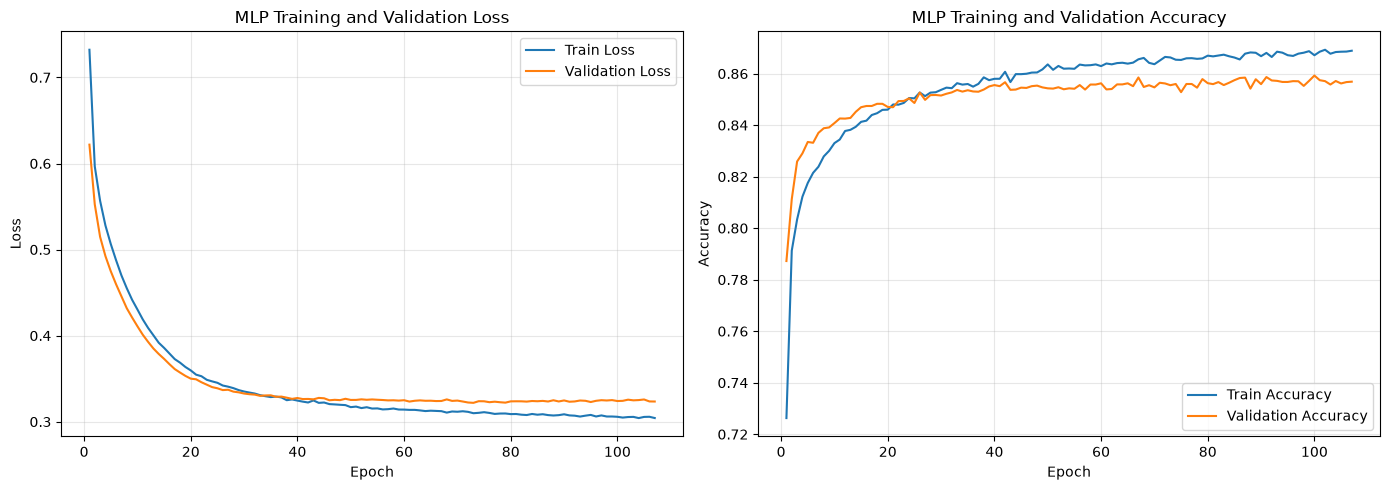

In [54]:
# ── 원본 셀 37 | 검증용 학습의 Loss·Accuracy 곡선 ──
# selected_history.history를 DataFrame으로 바꾸고 학습/검증 곡선을 나란히 그린다.
# Loss는 낮을수록 좋고 Accuracy는 높을수록 좋다. Train만 계속 개선되고 Validation이 정체되면 일반화 개선이 줄어든 상태로 볼 수 있다.
# 이 모델의 loss에는 설정한 L2 항도 포함될 수 있어 정규화가 다른 모델끼리 loss 절댓값만으로 우열을 판단하지 않는다.
# plt.show는 화면 표시이며 PNG 저장은 하지 않는다. 기록 CSV는 뒤 저장 셀에서 생성한다.

# Accuracy / Loss 그래프
import matplotlib.pyplot as plt

# [해설] history에는 loss/accuracy와 val_loss/val_accuracy 등 Epoch별 목록이 들어 있다.
history_df = pd.DataFrame(
    selected_history.history
)

epochs = range(
    1,
    len(history_df) + 1
)

# [해설] 1행 2열의 그림 공간을 만들고 axes[0], axes[1]에 각각 그린다.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Loss 그래프
axes[0].plot(
    epochs,
    history_df["loss"],
    label="Train Loss"
)

axes[0].plot(
    epochs,
    history_df["val_loss"],
    label="Validation Loss"
)

axes[0].set_title("MLP Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy 그래프
axes[1].plot(
    epochs,
    history_df["accuracy"],
    label="Train Accuracy"
)

axes[1].plot(
    epochs,
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

axes[1].set_title("MLP Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

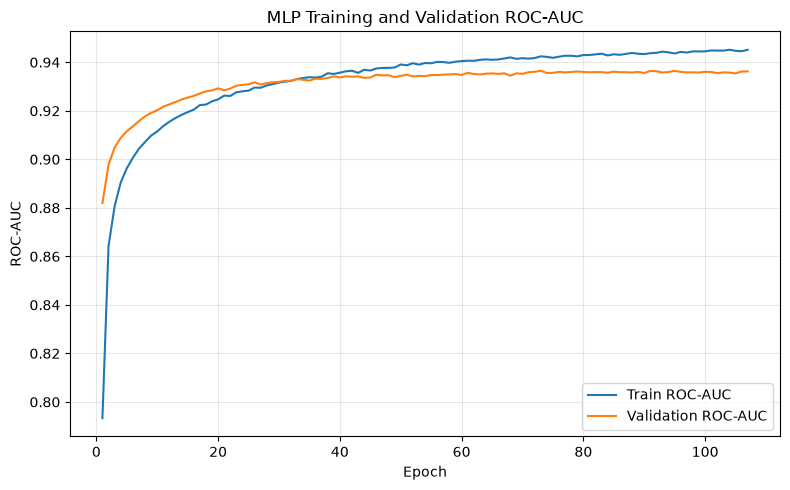

In [55]:
# ── 원본 셀 38 | 검증용 학습의 ROC-AUC 변화 ──
# 가로축 Epoch, 세로축 ROC-AUC의 학습 곡선이다.
# 가로축 FPR·세로축 TPR인 ROC Curve와 다른 그래프이다. AUC의 Epoch별 변화로 학습 상태를 확인한다.
# 같은 history_df와 epochs를 사용하므로 앞 셀 또는 저장 CSV에서 이 변수들을 준비해야 한다.

# ROC-AUC 그래프
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_df["roc_auc"],
    label="Train ROC-AUC"
)

plt.plot(
    epochs,
    history_df["val_roc_auc"],
    label="Validation ROC-AUC"
)

plt.title("MLP Training and Validation ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── 원본 셀 39 | 지표별 최고 Epoch 조회 ──
# idxmin/idxmax는 0부터 시작하는 행 위치이므로 출력 Epoch에 1을 더한다.
# 최소 Loss·최대 Accuracy·최대 ROC-AUC는 평가 관점이 달라 같은 Epoch일 필요가 없다.
# 이 셀은 위치를 출력할 뿐 모델 가중치를 변경하거나 최고 모델을 저장하지 않는다.

best_loss_epoch = (
    history_df["val_loss"].idxmin() + 1
)

best_accuracy_epoch = (
    history_df["val_accuracy"].idxmax() + 1
)

# [해설] 최대값 위치만 찾는다. 이 Epoch의 가중치를 파일에서 불러오지는 않는다.
best_auc_epoch = (
    history_df["val_roc_auc"].idxmax() + 1
)

print(
    "Validation Loss 최소 Epoch:",
    best_loss_epoch,
    "|",
    history_df.loc[
        best_loss_epoch - 1,
        "val_loss"
    ]
)

print(
    "Validation Accuracy 최고 Epoch:",
    best_accuracy_epoch,
    "|",
    history_df.loc[
        best_accuracy_epoch - 1,
        "val_accuracy"
    ]
)

print(
    "Validation ROC-AUC 최고 Epoch:",
    best_auc_epoch,
    "|",
    history_df.loc[
        best_auc_epoch - 1,
        "val_roc_auc"
    ]
)

Validation Loss 최소 Epoch: 73 | 0.32192179560661316
Validation Accuracy 최고 Epoch: 100 | 0.8592514395713806
Validation ROC-AUC 최고 Epoch: 73 | 0.9364886283874512


In [58]:
# ── 원본 셀 40 | 검증용 MLP의 기본 임계값 평가 ──
# selected_mlp_val의 현재 가중치로 Validation을 예측한다. 이 흐름에서는 107 Epoch 학습 종료 모델이다.
# 0.5에서 분류 성능을 계산하고 확률을 그대로 사용해 ROC-AUC를 계산한다.
# 혼동행렬은 [[TN, FP], [FN, TP]]이다. 취소를 놓친 건수는 FN, 정상 예약을 취소로 오인한 건수는 FP이다.
# 그래프의 최고 val_roc_auc 수치와 현재 모델의 ROC-AUC가 같아야 하는 것은 아니다.

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Validation 취소확률 예측
selected_val_proba = selected_mlp_val.predict(
    X_val_dl,
    batch_size=2048,
    verbose=0
).ravel()

# 기본 임계값 0.5 적용
default_threshold = 0.5

selected_val_pred_05 = (
    selected_val_proba >= default_threshold
).astype(int)

# 평가 결과
mlp_default_metrics = {
    "threshold": default_threshold,
    "accuracy": accuracy_score(
        y_val_dl,
        selected_val_pred_05
    ),
    "precision": precision_score(
        y_val_dl,
        selected_val_pred_05,
        zero_division=0
    ),
    "recall": recall_score(
        y_val_dl,
        selected_val_pred_05,
        zero_division=0
    ),
    "f1": f1_score(
        y_val_dl,
        selected_val_pred_05,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_val_dl,
        selected_val_proba
    )
}

print("MLP Validation 성능")
print("Threshold:", mlp_default_metrics["threshold"])
print(
    "Accuracy :",
    round(mlp_default_metrics["accuracy"], 4)
)
print(
    "Precision:",
    round(mlp_default_metrics["precision"], 4)
)
print(
    "Recall   :",
    round(mlp_default_metrics["recall"], 4)
)
print(
    "F1       :",
    round(mlp_default_metrics["f1"], 4)
)
print(
    "ROC-AUC  :",
    round(mlp_default_metrics["roc_auc"], 4)
)

print("\nConfusion Matrix")
print(
    confusion_matrix(
        y_val_dl,
        selected_val_pred_05
    )
)

MLP Validation 성능
Threshold: 0.5
Accuracy : 0.8569
Precision: 0.8183
Recall   : 0.7916
F1       : 0.8047
ROC-AUC  : 0.9363

Confusion Matrix
[[10660  1242]
 [ 1473  5595]]


In [59]:
# ── 원본 셀 41 | 검증용 모델·확률·학습 기록 저장 ──
# 평가 요약, 예약별 Validation 확률, 107 Epoch 전체 history, 검증용 .keras 모델을 저장한다.
# 이 history CSV에 train/val 열이 함께 있으므로 대시보드 학습 곡선의 원본으로 사용한다.
# 예측 CSV에는 원본 예약 인덱스가 없다. ADR·숙박일을 붙일 때 같은 Validation 행 순서를 확인해야 한다.
# 여기서는 검증용 전처리기를 별도 저장하지 않는다. 모델에 대응하는 Sub-train용 전처리기 버전도 함께 관리해야 한다.

import os
import pandas as pd
from sklearn.metrics import confusion_matrix

VALIDATION_DIR = "model_dl/validation"
os.makedirs(VALIDATION_DIR, exist_ok=True)

# 혼동행렬 값
tn, fp, fn, tp = confusion_matrix(
    y_val_dl,
    selected_val_pred_05
).ravel()

# 1. 평가 결과 저장
mlp_validation_result = pd.DataFrame([{
    "model": "Selected MLP",
    "data_split": "validation",
    "epochs": 107,
    "threshold": 0.5,
    "accuracy": mlp_default_metrics["accuracy"],
    "precision": mlp_default_metrics["precision"],
    "recall": mlp_default_metrics["recall"],
    "f1": mlp_default_metrics["f1"],
    "roc_auc": mlp_default_metrics["roc_auc"],
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp
}])

mlp_validation_result.to_csv(
    f"{VALIDATION_DIR}/mlp_validation_threshold_05.csv",
    index=False,
    encoding="utf-8-sig"
)

# 2. 임계값 실험에 사용할 예측확률 저장
mlp_validation_predictions = pd.DataFrame({
    "y_true": np.asarray(y_val_dl).ravel(),
    "cancel_probability": selected_val_proba,
    "prediction_threshold_05": selected_val_pred_05
})

mlp_validation_predictions.to_csv(
    f"{VALIDATION_DIR}/mlp_validation_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

# 3. 107 Epoch 학습 기록 저장
history_df.to_csv(
    f"{VALIDATION_DIR}/mlp_validation_history.csv",
    index=False,
    encoding="utf-8-sig"
)

# 4. 현재 검증용 모델 저장
# [해설] 파일명처럼 107 Epoch 종료 시점의 검증용 모델을 저장한다.
selected_mlp_val.save(
    f"{VALIDATION_DIR}/selected_mlp_validation_epoch107.keras"
)

print("저장 완료")
print(f"{VALIDATION_DIR}/mlp_validation_threshold_05.csv")
print(f"{VALIDATION_DIR}/mlp_validation_predictions.csv")
print(f"{VALIDATION_DIR}/mlp_validation_history.csv")
print(f"{VALIDATION_DIR}/selected_mlp_validation_epoch107.keras")

저장 완료
model_dl/validation/mlp_validation_threshold_05.csv
model_dl/validation/mlp_validation_predictions.csv
model_dl/validation/mlp_validation_history.csv
model_dl/validation/selected_mlp_validation_epoch107.keras


## 09. Validation Accuracy 기준 임계값 선택

확률은 고정하고 분류 기준만 변경한다. 재학습하지 않으며 Test로 임계값을 정하지 않는다.


In [60]:
# ── 원본 셀 42 | Validation Accuracy 기준 임계값 탐색 ──
# 저장 확률 하나에 대해 0.200~0.800을 0.001 간격으로 바꾸어 601개 기준을 평가한다.
# 가중치 학습이나 새 예측이 아니라 확률을 0/1로 바꾸는 기준만 바꾸는 실험이다.
# 최고 Accuracy에 np.isclose로 가까운 후보 중 0.5에 가장 가까운 기준을 선택한다. 전 범위의 수학적 최적점을 찾는 코드는 아니다.
# ROC-AUC는 확률 기반이라 이 임계값 변화로 바뀌지 않는다. Test는 임계값 선택에 사용하지 않는다.

import json
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

VALIDATION_DIR = "model_dl/validation"

# 저장된 Validation 예측 결과 불러오기
prediction_df = pd.read_csv(
    f"{VALIDATION_DIR}/mlp_validation_predictions.csv"
)

y_true = prediction_df["y_true"].to_numpy()
val_proba = prediction_df[
    "cancel_probability"
].to_numpy()

# 0.200~0.800, 0.001 간격
# [해설] 0.001 간격 탐색에서 부동소수점 표현을 소수 셋째 자리로 맞춘다.
thresholds = np.round(
    np.arange(0.200, 0.801, 0.001),
    3
)

threshold_results = []

for threshold in thresholds:
    prediction = (
        val_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_true,
            prediction
        ),
        "precision": precision_score(
            y_true,
            prediction,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            prediction,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            prediction,
            zero_division=0
        ),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

mlp_threshold_df = pd.DataFrame(
    threshold_results
)

# 최고 Accuracy
max_accuracy = mlp_threshold_df[
    "accuracy"
].max()

# 최고 Accuracy가 같은 임계값이 여러 개면
# 기본 임계값 0.5와 가장 가까운 값 선택
# [해설] np.isclose는 엄밀한 ==가 아니라 허용오차 내의 가까움을 판정한다.
best_candidates = mlp_threshold_df[
    np.isclose(
        mlp_threshold_df["accuracy"],
        max_accuracy
    )
].copy()

best_candidates["distance_from_05"] = (
    best_candidates["threshold"] - 0.5
).abs()

mlp_best_result = (
    best_candidates
    .sort_values("distance_from_05")
    .iloc[0]
)

mlp_best_threshold = float(
    mlp_best_result["threshold"]
)

mlp_val_roc_auc = roc_auc_score(
    y_true,
    val_proba
)

print("MLP Accuracy 최적 임계값:", mlp_best_threshold)
print("Validation Accuracy :", round(mlp_best_result["accuracy"], 4))
print("Validation Precision:", round(mlp_best_result["precision"], 4))
print("Validation Recall   :", round(mlp_best_result["recall"], 4))
print("Validation F1       :", round(mlp_best_result["f1"], 4))
print("Validation ROC-AUC  :", round(mlp_val_roc_auc, 4))

print("\nConfusion Matrix")
print([
    [int(mlp_best_result["tn"]), int(mlp_best_result["fp"])],
    [int(mlp_best_result["fn"]), int(mlp_best_result["tp"])]
])

print("\nAccuracy 기준 상위 10개")
display(
    mlp_threshold_df
    .sort_values(
        ["accuracy", "f1"],
        ascending=[False, False]
    )
    .head(10)
)

MLP Accuracy 최적 임계값: 0.511
Validation Accuracy : 0.8572
Validation Precision: 0.8232
Validation Recall   : 0.7857
Validation F1       : 0.804
Validation ROC-AUC  : 0.9363

Confusion Matrix
[[10709, 1193], [1515, 5553]]

Accuracy 기준 상위 10개


,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp
311,0.511,0.857248,0.823154,0.785654,0.803967,10709,1193,1515,5553
312,0.512,0.857196,0.823416,0.785088,0.803795,10712,1190,1519,5549
305,0.505,0.857090,0.820887,0.788483,0.804359,10686,1216,1495,5573
293,0.493,0.857037,0.815013,0.797255,0.806036,10623,1279,1433,5635
306,0.506,0.857037,0.821050,0.788059,0.804216,10688,1214,1498,5570
313,0.513,0.856985,0.823503,0.784239,0.803392,10714,1188,1525,5543
307,0.507,0.856932,0.821376,0.787210,0.803930,10692,1210,1504,5564
314,0.514,0.856932,0.824055,0.783248,0.803134,10720,1182,1532,5536
316,0.516,0.856932,0.824635,0.782400,0.802962,10726,1176,1538,5530
322,0.522,0.856932,0.827467,0.778297,0.802129,10755,1147,1567,5501


In [61]:
# ── 원본 셀 43 | 기본·최적 임계값 비교표 ──
# 0.5와 선택된 기준의 Accuracy·Precision·Recall·F1·혼동행렬을 한 표로 묶는다.
# ROC-AUC는 같은 확률로 계산한 값이므로 두 행이 같다.
# Accuracy를 높이는 기준이 Recall·F1도 동시에 높인다는 뜻은 아니다.

default_result = mlp_threshold_df[
    np.isclose(
        mlp_threshold_df["threshold"],
        0.5
    )
].iloc[0]

comparison_df = pd.DataFrame([
    {
        "type": "기본 임계값",
        # [해설] 사전 펼치기로 기본 기준의 지표를 이 행에 합친다.
        **default_result.to_dict(),
        "roc_auc": mlp_val_roc_auc
    },
    {
        "type": "Accuracy 최적 임계값",
        **mlp_best_result.drop(
            labels=["distance_from_05"],
            errors="ignore"
        ).to_dict(),
        "roc_auc": mlp_val_roc_auc
    }
])

display(
    comparison_df[
        [
            "type",
            "threshold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "tn",
            "fp",
            "fn",
            "tp"
        ]
    ]
)

,type,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,기본 임계값,0.500,0.856879,0.818341,0.791596,0.804746,0.936298,10660.0,1242.0,1473.0,5595.0
1,Accuracy 최적 임계값,0.511,0.857248,0.823154,0.785654,0.803967,0.936298,10709.0,1193.0,1515.0,5553.0


In [62]:
# ── 원본 셀 44 | 임계값 결과와 선택 기준 저장 ──
# 601개 전체 결과 CSV, 두 기준 비교 CSV, 선택된 기준 JSON을 저장한다.
# JSON의 selection_metric은 validation_accuracy이다. 모델 구조 선정의 ROC-AUC 기준과 역할이 다르다.

mlp_threshold_df.to_csv(
    f"{VALIDATION_DIR}/mlp_threshold_search.csv",
    index=False,
    encoding="utf-8-sig"
)

comparison_df.to_csv(
    f"{VALIDATION_DIR}/mlp_threshold_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

with open(
    f"{VALIDATION_DIR}/mlp_best_threshold.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        {
            "selection_metric": "validation_accuracy",
            "best_threshold": mlp_best_threshold,
            "validation_accuracy": float(
                mlp_best_result["accuracy"]
            ),
            "validation_roc_auc": float(
                mlp_val_roc_auc
            )
        },
        file,
        ensure_ascii=False,
        indent=2
    )

print("임계값 탐색 결과 저장 완료")

임계값 탐색 결과 저장 완료


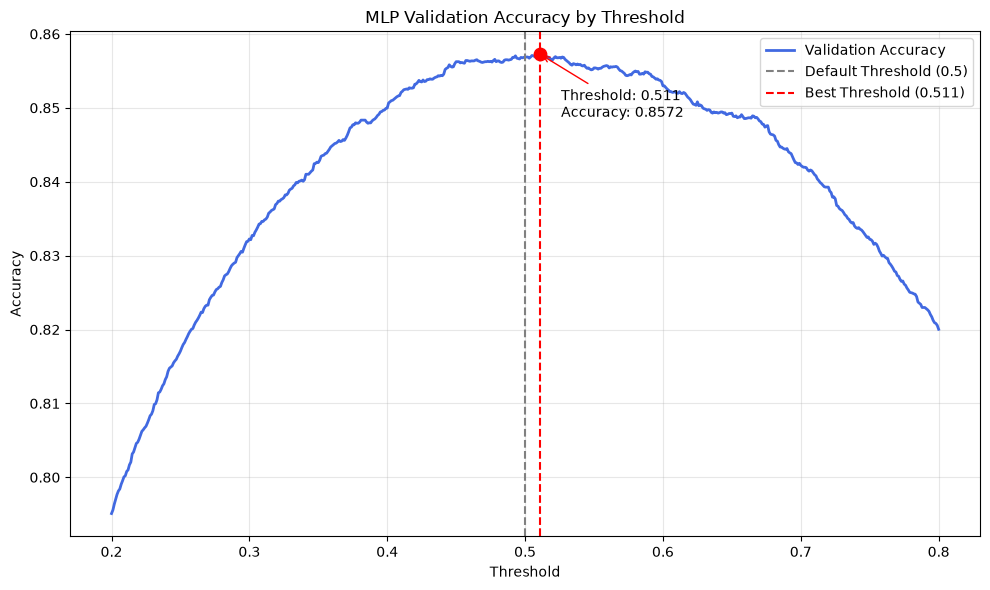

In [63]:
# ── 원본 셀 45 | Accuracy와 임계값 관계 시각화 ──
# 회색 선은 기본 0.5, 빨간 선과 점은 선택된 Accuracy 기준을 뜻한다.
# 저장된 Validation 결과를 그리는 것이며 새 학습은 없다. 300 dpi PNG를 같은 경로에 저장한다.

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 임계값별 Accuracy
plt.plot(
    mlp_threshold_df["threshold"],
    mlp_threshold_df["accuracy"],
    color="royalblue",
    linewidth=2,
    label="Validation Accuracy"
)

# 기본 임계값 0.5
plt.axvline(
    0.5,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Default Threshold (0.5)"
)

# Accuracy 최적 임계값
plt.axvline(
    mlp_best_threshold,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Best Threshold "
        f"({mlp_best_threshold:.3f})"
    )
)

# 최고점 표시
plt.scatter(
    mlp_best_threshold,
    mlp_best_result["accuracy"],
    color="red",
    s=80,
    zorder=3
)

plt.annotate(
    (
        f"Threshold: {mlp_best_threshold:.3f}\n"
        f"Accuracy: {mlp_best_result['accuracy']:.4f}"
    ),
    xy=(
        mlp_best_threshold,
        mlp_best_result["accuracy"]
    ),
    xytext=(15, -45),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
        "color": "red"
    }
)

plt.title("MLP Validation Accuracy by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# 발표자료용 이미지 저장
plt.savefig(
    f"{VALIDATION_DIR}/mlp_threshold_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

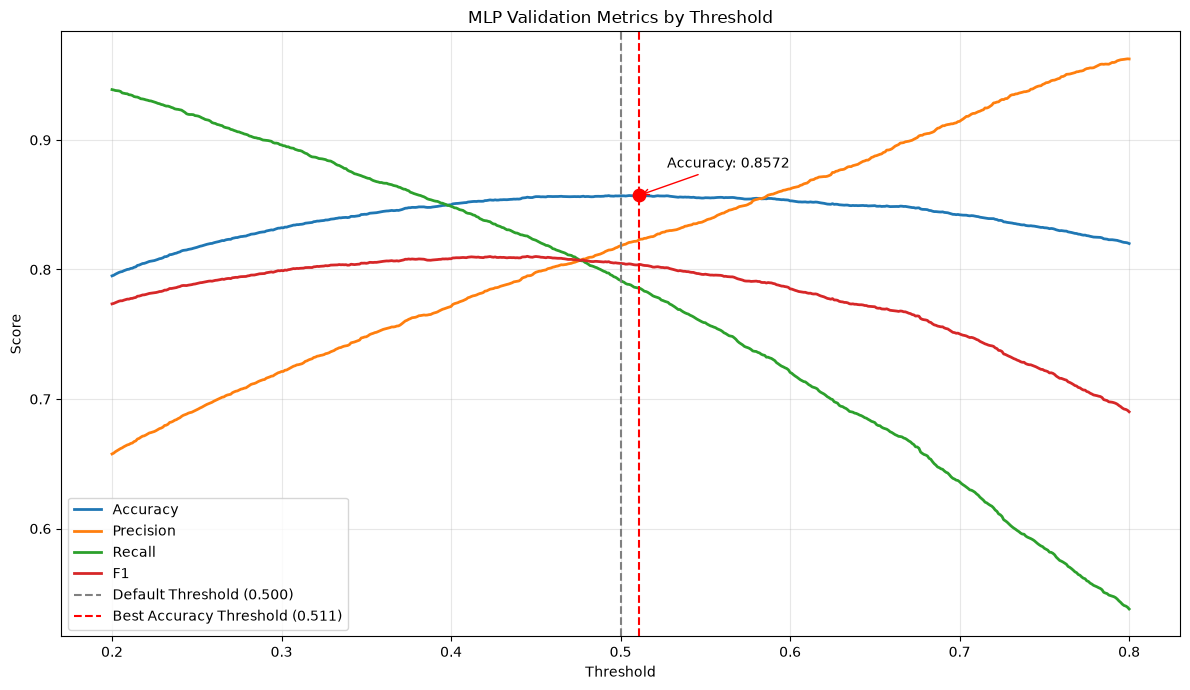

In [64]:
# ── 원본 셀 46 | 임계값별 네 지표의 변화 시각화 ──
# Accuracy·Precision·Recall·F1 곡선으로 분류 기준의 상충 관계를 확인한다.
# 임계값을 올리면 취소로 분류되는 예약 수는 줄거나 같아지고 Recall도 줄거나 같다. Precision은 데이터에 따라 항상 단조 증가하지는 않는다.
# 이 그래프에서 Test 결과를 보고 임계값을 다시 선택하지 않는다. PNG 파일을 저장한다.

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.plot(
    mlp_threshold_df["threshold"],
    mlp_threshold_df["accuracy"],
    label="Accuracy",
    linewidth=2
)

plt.plot(
    mlp_threshold_df["threshold"],
    mlp_threshold_df["precision"],
    label="Precision",
    linewidth=2
)

plt.plot(
    mlp_threshold_df["threshold"],
    mlp_threshold_df["recall"],
    label="Recall",
    linewidth=2
)

plt.plot(
    mlp_threshold_df["threshold"],
    mlp_threshold_df["f1"],
    label="F1",
    linewidth=2
)

# 기본 임계값
plt.axvline(
    0.5,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Default Threshold (0.500)"
)

# Accuracy 최적 임계값
plt.axvline(
    mlp_best_threshold,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Best Accuracy Threshold "
        f"({mlp_best_threshold:.3f})"
    )
)

# 최적 Accuracy 지점
plt.scatter(
    mlp_best_threshold,
    mlp_best_result["accuracy"],
    color="red",
    s=80,
    zorder=3
)

plt.annotate(
    (
        f"Accuracy: "
        f"{mlp_best_result['accuracy']:.4f}"
    ),
    xy=(
        mlp_best_threshold,
        mlp_best_result["accuracy"]
    ),
    xytext=(20, 20),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
        "color": "red"
    }
)

plt.title(
    "MLP Validation Metrics by Threshold"
)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{VALIDATION_DIR}/mlp_threshold_all_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. 전체 Train으로 최종 재학습·저장

**파일 갱신 주의:** 최종 모델과 전처리기를 새로 학습·저장한다. 단순 시각화 목적이면 실행할 필요가 없다.


In [66]:
# ── 원본 셀 47 | 최종 전체 Train 재학습 설정 ──
# 앞 단계에서 선택한 구조와 임계값을 고정하고 최종 학습 경로를 준비한다.
# FINAL_EPOCHS=107은 여기 코드에 고정되어 있다. OPTIMIZED_THRESHOLD는 메모리의 mlp_best_threshold에 의존한다.
# 커널 재시작 후에는 선택된 임계값을 저장 JSON에서 복원하거나 관련 셀을 준비해야 한다.

import os
import json
import time
import random
import joblib

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.base import clone

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import (
    Dense,
    BatchNormalization,
    Dropout
)
from tensorflow.keras.regularizers import l2

FINAL_DIR = "model_dl/final"
os.makedirs(FINAL_DIR, exist_ok=True)

FINAL_EPOCHS = 107
DEFAULT_THRESHOLD = 0.5
OPTIMIZED_THRESHOLD = float(
    mlp_best_threshold
)

print("최종 Epoch:", FINAL_EPOCHS)
print("기본 임계값:", DEFAULT_THRESHOLD)
print("Accuracy 최적 임계값:", OPTIMIZED_THRESHOLD)

최종 Epoch: 107
기본 임계값: 0.5
Accuracy 최적 임계값: 0.511


In [67]:
# ── 원본 셀 48 | 최종 전처리기를 전체 Train으로 학습 ──
# Sub-train용 전처리기와 별도로 전체 X_train에 fit_transform한다. 기존 Validation 예약도 이제 Train에 포함된다.
# Test에는 transform만 적용한다. 이는 Test로 평균·표준편차를 학습하지 않는다는 뜻이다.
# X_train_final/X_test_final은 최종 모델 전용이다. 검증용 X_val_dl과 최종 모델을 섞어 쓰지 않는다.

# 기존 전처리기 구조를 복제
# clone()은 학습된 정보를 가져오지 않고 구조만 복제
preprocessor_final = clone(
    preprocessor
)

# 전체 X_train으로 전처리기 학습
# [해설] 전체 Train에 새 전처리기를 학습한다. 검증용 전처리기에 덮어 fit하는 방식은 아니다.
X_train_final = preprocessor_final.fit_transform(
    X_train
).astype("float32")

# 최종 평가를 위한 X_test 변환
# X_test로 전처리기를 학습하지는 않음
X_test_final = preprocessor_final.transform(
    X_test
).astype("float32")

y_train_final = y_train.to_numpy(
    dtype="float32"
)

y_test_final = y_test.to_numpy(
    dtype="float32"
)

print("Final Train:", X_train_final.shape)
print("Final Test :", X_test_final.shape)
print("Train Target:", y_train_final.shape)
print("Test Target :", y_test_final.shape)

Final Train: (94848, 64)
Final Test : (23712, 64)
Train Target: (94848,)
Test Target : (23712,)


In [68]:
# ── 원본 셀 49 | 최종 배포 전처리기 저장 ──
# final_mlp_preprocessor.joblib에 최종 Train 기준 변환기를 저장한다.
# 이 파일을 갱신하면 기존 final_mlp.keras와 맞지 않을 수 있다. 재학습 시 모델·전처리기는 한 쌍으로 관리한다.

FINAL_PREPROCESSOR_PATH = (
    f"{FINAL_DIR}/final_mlp_preprocessor.joblib"
)

joblib.dump(
    preprocessor_final,
    FINAL_PREPROCESSOR_PATH
)

print(
    "최종 전처리기 저장:",
    FINAL_PREPROCESSOR_PATH
)

최종 전처리기 저장: model_dl/final/final_mlp_preprocessor.joblib


In [69]:
# ── 원본 셀 50 | 최종 배포 MLP 구성 ──
# 선정한 256-128-64 구조와 3개의 BatchNorm/Dropout을 새 가중치로 초기화한다.
# 검증용 가중치를 이어 학습하는 것이 아니라 전체 Train용 새 모델을 만드는 것이다.
# 시드 설정은 재현성을 돕지만 장치·버전·연산 차이에 따른 작은 차이까지 없애지는 않는다.

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

tf.keras.backend.clear_session()

final_mlp = Sequential([
    Input(shape=(X_train_final.shape[1],)),

    Dense(
        256,
        activation="relu",
        kernel_regularizer=l2(0.0005)
    ),
    BatchNormalization(),
    Dropout(0.4),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.0005)
    ),
    BatchNormalization(),
    Dropout(0.4),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(0.0005)
    ),
    BatchNormalization(),
    Dropout(0.4),

    Dense(
        1,
        activation="sigmoid"
    )
])

final_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.AUC(
            name="roc_auc"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

final_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,649 (233.00 KB)

 Trainable params: 58,753 (229.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [70]:
# ── 원본 셀 51 | 전체 Train으로 최종 107 Epoch 학습 ──
# 학습 셀: X_train_final/y_train_final 전체를 사용하고 사전에 확정한 길이만큼 학습한다.
# Validation 데이터·EarlyStopping·ReduceLROnPlateau를 전달하지 않는다. 따라서 val_loss 같은 기록이 생기지 않는다.
# 선정 단계와 최종 재학습 단계의 학습률 운용 조건이 다르며 반복 검증 평균과 최종 Test 값은 직접 같은 값으로 취급하지 않는다.

start_time = time.perf_counter()

# [해설] 전체 Train 학습. validation_data가 없어서 history에 val_* 열이 생기지 않는다.
final_history = final_mlp.fit(
    X_train_final,
    y_train_final,
    epochs=FINAL_EPOCHS,
    batch_size=512,
    shuffle=True,
    verbose=1
)

final_training_seconds = (
    time.perf_counter() - start_time
)

print(
    "최종 MLP 학습 시간:",
    round(
        final_training_seconds / 60,
        2
    ),
    "분"
)

Epoch 1/107
186/186 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7367 - loss: 0.7104 - precision: 0.6455 - recall: 0.6508 - roc_auc: 0.8051
Epoch 2/107
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7988 - loss: 0.5809 - precision: 0.7684 - recall: 0.6583 - roc_auc: 0.8710
Epoch 3/107
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8080 - loss: 0.5399 - precision: 0.7838 - recall: 0.6693 - roc_auc: 0.8858
Epoch 4/107
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8160 - loss: 0.5120 - precision: 0.7940 - recall: 0.6834 - roc_auc: 0.8939
Epoch 5/107
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8202 - loss: 0.4873 - precision: 0.7970 - recall: 0.6942 - roc_auc: 0.8997
Epoch 6/107
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8251 - loss: 0.4659 - precision: 0.8025 - recall: 0.7039 - roc_auc: 0.9046
Epoch 7/107
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8270 - loss: 0.4486 - precision: 0.8018 - recall: 0.7117 - roc_auc: 0.9074
Ep

In [71]:
# ── 원본 셀 52 | 배포용 모델·설정·학습 기록 저장 ──
# final_mlp.keras는 신경망, final_mlp_history.csv는 Train만 있는 최종 학습 곡선, JSON은 설정·임계값을 담는다.
# 이전 final_mlp_preprocessor.joblib과 함께 배포해야 한다.
# 같은 이름 파일을 덮어쓰므로 현재 배포 모델을 보존하려면 이 셀을 무심코 재실행하지 않는다.

FINAL_MODEL_PATH = (
    f"{FINAL_DIR}/final_mlp.keras"
)

FINAL_HISTORY_PATH = (
    f"{FINAL_DIR}/final_mlp_history.csv"
)

FINAL_CONFIG_PATH = (
    f"{FINAL_DIR}/final_mlp_config.json"
)

# 최종 모델 저장
# [해설] 추론에 사용할 가중치와 모델 구조를 .keras 파일로 저장한다.
final_mlp.save(
    FINAL_MODEL_PATH
)

# 학습 기록 저장
# [해설] 이 CSV는 Train 전용 기록이다. 검증용 history CSV와 구분한다.
final_history_df = pd.DataFrame(
    final_history.history
)

final_history_df.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(final_history_df) + 1
    )
)

final_history_df.to_csv(
    FINAL_HISTORY_PATH,
    index=False,
    encoding="utf-8-sig"
)

# 설정 및 임계값 저장
final_config = {
    "model_type": "MLP Binary Classifier",
    "units": [256, 128, 64],
    "hidden_activation": "relu",
    "output_activation": "sigmoid",
    "optimizer": "Adam",
    "learning_rate": 0.0005,
    "dropout": 0.4,
    "l2": 0.0005,
    "batch_size": 512,
    "batch_norm": True,
    "final_epochs": FINAL_EPOCHS,
    "input_features": int(
        X_train_final.shape[1]
    ),
    "default_threshold": DEFAULT_THRESHOLD,
    "optimized_threshold": OPTIMIZED_THRESHOLD,
    "threshold_selection_metric": (
        "validation_accuracy"
    ),
    "final_training_seconds": float(
        final_training_seconds
    )
}

with open(
    FINAL_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        final_config,
        file,
        ensure_ascii=False,
        indent=2
    )

print("최종 저장 완료")
print(FINAL_MODEL_PATH)
print(FINAL_PREPROCESSOR_PATH)
print(FINAL_HISTORY_PATH)
print(FINAL_CONFIG_PATH)

최종 저장 완료
model_dl/final/final_mlp.keras
model_dl/final/final_mlp_preprocessor.joblib
model_dl/final/final_mlp_history.csv
model_dl/final/final_mlp_config.json


## 11. 최종 Test 평가·저장

고정된 0.5와 Validation 최적 임계값을 평가한다. 저장 확률 CSV로 ROC Curve 등을 다시 만들 수 있다.


In [72]:
# ── 원본 셀 53 | 저장된 최종 모델·전처리기·설정 로드 ──
# 재학습 없이 디스크에서 배포 모델 한 쌍과 JSON의 두 임계값을 읽는다.
# 커널이 재시작돼도 이 파일들을 불러오면 예측 가능하다. 단 입력 X_test/y_test는 별도로 복원되어 있어야 한다.

import json
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

FINAL_DIR = "model_dl/final"

# 저장된 전처리기 불러오기
loaded_final_preprocessor = joblib.load(
    f"{FINAL_DIR}/final_mlp_preprocessor.joblib"
)

# 저장된 최종 모델 불러오기
loaded_final_mlp = tf.keras.models.load_model(
    f"{FINAL_DIR}/final_mlp.keras"
)

# 저장된 설정 불러오기
with open(
    f"{FINAL_DIR}/final_mlp_config.json",
    "r",
    encoding="utf-8"
) as file:
    loaded_final_config = json.load(file)

default_threshold = float(
    loaded_final_config["default_threshold"]
)

optimized_threshold = float(
    loaded_final_config["optimized_threshold"]
)

print("기본 임계값:", default_threshold)
print("최적 임계값:", optimized_threshold)

기본 임계값: 0.5
최적 임계값: 0.511


In [73]:
# ── 원본 셀 54 | 최종 Test 확률 예측 ──
# 저장된 최종 전처리기로 Test를 변환한 뒤 최종 모델로 확률을 계산한다.
# ravel은 (예약 수, 1)을 (예약 수,)로 펴는 배열 모양 변환이며 신경망 Flatten 층이나 확률 보정이 아니다.
# 출력 범위를 round(..., 4)로 표시해 0.0이 나와도 원래 확률이 정확히 0이라는 뜻은 아니다.

# 저장된 전처리기를 이용한 Test 변환
X_test_loaded = loaded_final_preprocessor.transform(
    X_test
).astype("float32")

y_test_loaded = y_test.to_numpy(
    dtype="int32"
)

print("Test 입력 형태:", X_test_loaded.shape)

# 최종 Test 취소확률 예측
# [해설] predict 시 Dropout은 꺼지고 BatchNorm은 저장된 이동 통계를 사용한다.
final_test_proba = loaded_final_mlp.predict(
    X_test_loaded,
    batch_size=2048,
    verbose=0
).ravel()

print(
    "예측확률 범위:",
    round(float(final_test_proba.min()), 4),
    "~",
    round(float(final_test_proba.max()), 4)
)

Test 입력 형태: (23712, 64)
예측확률 범위: 0.0 ~ 1.0


In [74]:
# ── 원본 셀 55 | 고정된 두 임계값으로 Test 평가 ──
# Validation에서 정한 기준과 기본 0.5를 Test에 적용한다. 이 셀은 Test에서 최적 임계값을 탐색하지 않는다.
# 두 행 모두 같은 final_test_proba를 사용하므로 ROC-AUC는 같고 분류 지표만 달라진다.
# test_predictions에는 각 임계값별 0/1 결과가 저장된다.

test_thresholds = [
    (
        "기본 임계값",
        default_threshold
    ),
    (
        "Validation Accuracy 최적 임계값",
        optimized_threshold
    )
]

test_results = []
test_predictions = {}

# [해설] ROC-AUC에는 이진 예측값이 아니라 연속 확률을 전달한다.
final_test_auc = roc_auc_score(
    y_test_loaded,
    final_test_proba
)

# [해설] 미리 정해진 두 임계값만 평가한다. Test 최적 임계값을 선택하는 루프가 아니다.
for threshold_type, threshold in test_thresholds:
    prediction = (
        final_test_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_loaded,
        prediction
    ).ravel()

    test_results.append({
        "model": "Final MLP",
        "threshold_type": threshold_type,
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_test_loaded,
            prediction
        ),
        "precision": precision_score(
            y_test_loaded,
            prediction,
            zero_division=0
        ),
        "recall": recall_score(
            y_test_loaded,
            prediction,
            zero_division=0
        ),
        "f1": f1_score(
            y_test_loaded,
            prediction,
            zero_division=0
        ),
        "roc_auc": final_test_auc,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    })

    test_predictions[
        f"prediction_threshold_{threshold:.3f}"
    ] = prediction

final_test_metrics_df = pd.DataFrame(
    test_results
)

display(final_test_metrics_df)

,model,threshold_type,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Final MLP,기본 임계값,0.500,0.860619,0.820766,0.800792,0.810656,0.939349,13332,1545,1760,7075
1,Final MLP,Validation Accuracy 최적 임계값,0.511,0.861884,0.828683,0.793322,0.810617,0.939349,13428,1449,1826,7009


In [75]:
# ── 원본 셀 56 | Test 혼동행렬 숫자 확인 ──
# 각 임계값 결과를 [[TN, FP], [FN, TP]]로 출력한다.
# 취소 예약 재현율을 중시하면 FN을, 불필요한 취소 경보를 줄이려면 FP와 Precision을 함께 해석한다.

for _, result in final_test_metrics_df.iterrows():
    print(
        f"\n{result['threshold_type']} "
        f"(Threshold {result['threshold']:.3f})"
    )

    print([
        [
            int(result["tn"]),
            int(result["fp"])
        ],
        [
            int(result["fn"]),
            int(result["tp"])
        ]
    ])


기본 임계값 (Threshold 0.500)
[[13332, 1545], [1760, 7075]]

Validation Accuracy 최적 임계값 (Threshold 0.511)
[[13428, 1449], [1826, 7009]]


In [76]:
# ── 원본 셀 57 | Test 평가·예측확률 CSV 저장 ──
# final_mlp_test_metrics.csv는 지표 요약, final_mlp_test_predictions.csv는 예약별 정답·확률이다.
# ROC Curve는 요약 AUC 하나가 아니라 이 예약별 확률 CSV로 다시 그릴 수 있다.
# 원본 예약 인덱스는 저장하지 않으므로 RF 결과 결합 시 공통 분할 인덱스/행 순서 확인이 필요하다.

# 최종 Test 지표 저장
final_test_metrics_df.to_csv(
    f"{FINAL_DIR}/final_mlp_test_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

# Test 예측 결과 저장
# [해설] 현재 저장 열에는 original_index가 없다. 이후 모델 간 행 대조 시 유의한다.
final_test_predictions_df = pd.DataFrame({
    "y_true": y_test_loaded,
    "cancel_probability": final_test_proba,
    **test_predictions
})

final_test_predictions_df.to_csv(
    f"{FINAL_DIR}/final_mlp_test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("최종 Test 평가 결과 저장 완료")
print(
    f"{FINAL_DIR}/final_mlp_test_metrics.csv"
)
print(
    f"{FINAL_DIR}/final_mlp_test_predictions.csv"
)

최종 Test 평가 결과 저장 완료
model_dl/final/final_mlp_test_metrics.csv
model_dl/final/final_mlp_test_predictions.csv


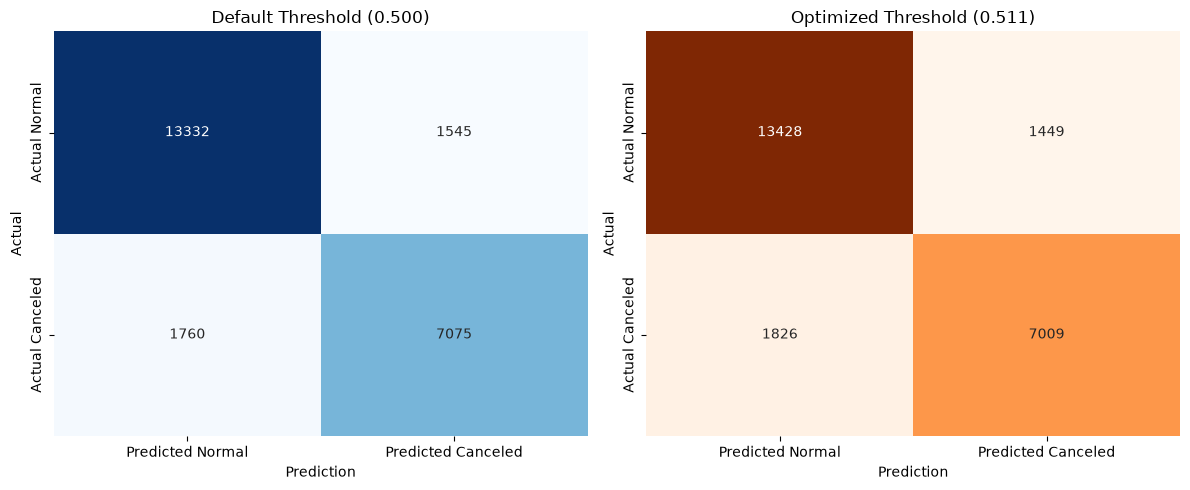

In [78]:
# ── 원본 셀 58 | MLP 임계값별 혼동행렬 이미지 ──
# 시각화/저장 셀: cm_default와 cm_optimized를 열지도로 그린다.
# 주의: 이 업로드 노트북에는 두 행렬 변수를 만드는 코드가 없다. 새 커널에서 바로 실행하면 NameError가 날 수 있다.
# 앞 Test 지표의 tn/fp/fn/tp 또는 y_test_loaded와 test_predictions로 행렬을 준비해야 한다. 이번 작업은 주석만 추가하므로 코드는 수정하지 않았다.

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# [해설] cm_default가 현재 커널에 준비되어 있어야 한다. 원본 노트북에 생성 코드가 빠져 있다.
sns.heatmap(
    cm_default,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Predicted Normal",
        "Predicted Canceled"
    ],
    yticklabels=[
        "Actual Normal",
        "Actual Canceled"
    ],
    ax=axes[0]
)

axes[0].set_title(
    f"Default Threshold ({default_threshold:.3f})"
)
axes[0].set_xlabel("Prediction")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_optimized,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    xticklabels=[
        "Predicted Normal",
        "Predicted Canceled"
    ],
    yticklabels=[
        "Actual Normal",
        "Actual Canceled"
    ],
    ax=axes[1]
)

axes[1].set_title(
    f"Optimized Threshold ({optimized_threshold:.3f})"
)
axes[1].set_xlabel("Prediction")
axes[1].set_ylabel("Actual")

plt.tight_layout()

plt.savefig(
    f"{FINAL_DIR}/final_mlp_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 12. 과거 RF·MLP 비교 — 최종 공통 비교로 사용 금지

이 구간은 기존 RF 23,713건과 MLP 23,712건의 결과를 사용한다. 최신 공통 RF 결과로 갱신할 작업은 별도이며, 이번에는 주석만 달았다.


In [1]:
# ── 원본 셀 59 | RF 결과 상대경로 확인 — 과거 비교 단계 ──
# 현재 작업 폴더와 형제 ML_PRJ 폴더의 기존 RF 평가 CSV 존재 여부를 확인한다.
# 이 경로는 공통 분할 RF가 아니라 model/evaluation/rf_test_metrics.csv를 가리킨다.

import os

print("현재 작업 경로:")
print(os.getcwd())

rf_metrics_path = (
    "../ML_PRJ/model/evaluation/rf_test_metrics.csv"
)

print("\nRF 파일 존재 여부:")
print(os.path.exists(rf_metrics_path))

현재 작업 경로:
d:\pythonscript\Deep_Learning_PRJ

RF 파일 존재 여부:
True


In [2]:
# ── 원본 셀 60 | 기존 RF·MLP 지표 로드 — 최신 공통 비교 아님 ──
# 이 셀은 과거 RF Test 23,713건 결과와 MLP Test 23,712건 결과를 읽는다.
# 최종 공정 비교에는 ML_PRJ/model_dl/comparison/rf_common_test_metrics.csv와 공통 Test 확인이 필요하다.
# 과거 작업 기록을 보존하기 위해 경로를 변경하지 않았다.

import pandas as pd

# MLP 최종 Test 평가 결과
mlp_metrics = pd.read_csv(
    "model_dl/final/final_mlp_test_metrics.csv"
)

# Random Forest 최종 Test 평가 결과
# [해설] 과거 RF 경로이다. 최신 공통 분할 comparison 폴더의 지표와 혼동하지 않는다.
rf_metrics = pd.read_csv(
    "../ML_PRJ/model/evaluation/rf_test_metrics.csv"
)

print("MLP 결과")
display(mlp_metrics.round(4))

print("Random Forest 결과")
display(rf_metrics.round(4))

MLP 결과


,model,threshold_type,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Final MLP,기본 임계값,0.500,0.8606,0.8208,0.8008,0.8107,0.9393,13332,1545,1760,7075
1,Final MLP,Validation Accuracy 최적 임계값,0.511,0.8619,0.8287,0.7933,0.8106,0.9393,13428,1449,1826,7009


Random Forest 결과


,model,threshold_type,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Moderate Random Forest,기본 임계값,0.5,0.8663,0.867,0.7573,0.8085,0.942,13852,1026,2144,6691


In [ ]:
# ── 원본 셀 61 | 기본 임계값 0.5 비교표 — 과거 결과 ──
# 두 결과에서 threshold=0.5 행만 선택해 지표 열을 맞춘다.
# 같은 임계값만으로 같은 평가 조건이 성립하지 않는다. 예약 구성·정답·행 순서·학습 데이터가 함께 맞아야 한다.
# 이 표는 앞의 기존 RF 파일을 그대로 사용하므로 공통 분할 최종 비교표로 오인하지 않는다.

# MLP 0.5 기본 임계값만 선택해서 비교

mlp_default = mlp_metrics[
    mlp_metrics["threshold"] == 0.5
].copy()

rf_default = rf_metrics[
    rf_metrics["threshold"] == 0.5
].copy()

model_comparison = pd.concat(
    [
        rf_default,
        mlp_default
    ],
    ignore_index=True
)

comparison_cols = [
    "model",
    "threshold",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "tn",
    "fp",
    "fn",
    "tp"
]

model_comparison = model_comparison[
    comparison_cols
]

display(
    model_comparison.round(4)
)

,model,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Moderate Random Forest,0.5,0.8663,0.8670,0.7573,0.8085,0.9420,13852,1026,2144,6691
1,Final MLP,0.5,0.8606,0.8208,0.8008,0.8107,0.9393,13332,1545,1760,7075


In [ ]:
# ── 원본 셀 62 | 과거 RF·MLP 비교표 저장 ──
# 현재 model_comparison을 rf_mlp_default_comparison.csv에 저장한다.
# 공통 분할 비교를 새로 만든 뒤 이 셀을 재실행하면 예전 값으로 다시 덮어쓸 수 있으므로 주의한다.

# RF vs MLP 임계값 0.5 비교표 저장

model_comparison.to_csv(
    "model_dl/final/rf_mlp_default_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "비교표 저장 완료:",
    "model_dl/final/rf_mlp_default_comparison.csv"
)

비교표 저장 완료: model_dl/final/rf_mlp_default_comparison.csv


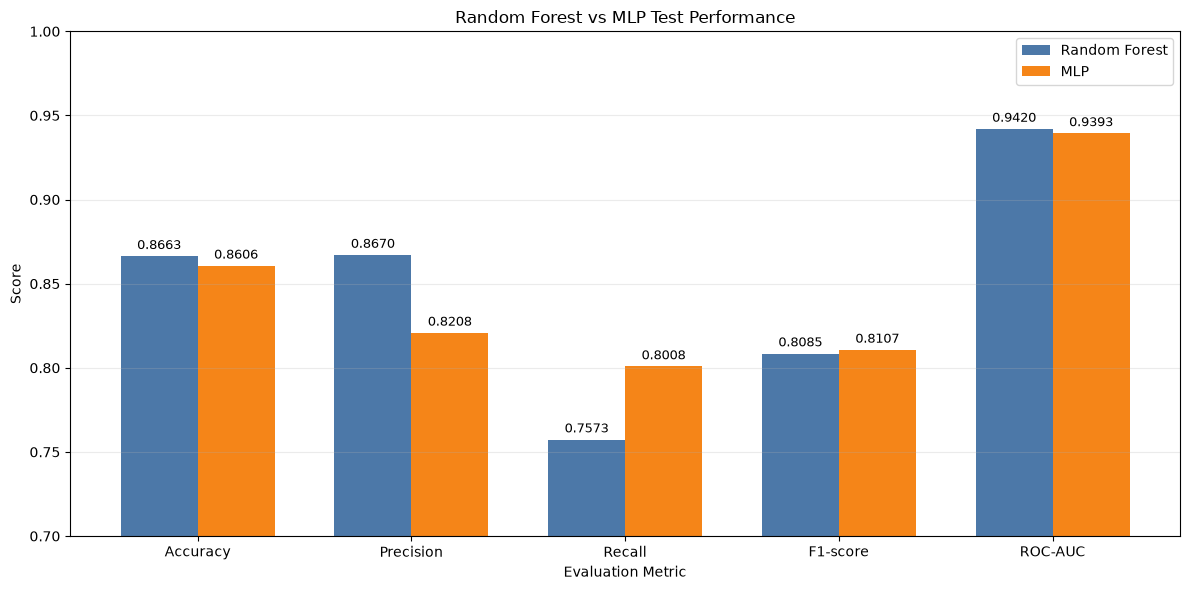

In [ ]:
# ── 원본 셀 63 | 과거 RF·MLP 다섯 지표 막대그래프 ──
# Accuracy·Precision·Recall·F1·ROC-AUC를 나란히 그리는 코드이다.
# 입력 표가 공통 분할 이전 데이터이므로 원본 그래프 역시 그 과거 비교에 해당한다.
# y축을 0.70부터 잘라 차이가 강조된다. 발표에서 축 범위를 확인하고 작은 차이를 과장하지 않는다.

# 성능 비교 그래프 시각화

import matplotlib.pyplot as plt
import numpy as np

metric_cols = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

metric_labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

rf_scores = (
    model_comparison
    .loc[
        model_comparison["model"]
        == "Moderate Random Forest",
        metric_cols
    ]
    .iloc[0]
    .to_numpy(dtype=float)
)

mlp_scores = (
    model_comparison
    .loc[
        model_comparison["model"]
        == "Final MLP",
        metric_cols
    ]
    .iloc[0]
    .to_numpy(dtype=float)
)

x = np.arange(
    len(metric_cols)
)

width = 0.36

fig, ax = plt.subplots(
    figsize=(12, 6)
)

rf_bars = ax.bar(
    x - width / 2,
    rf_scores,
    width,
    label="Random Forest",
    color="#4C78A8"
)

mlp_bars = ax.bar(
    x + width / 2,
    mlp_scores,
    width,
    label="MLP",
    color="#F58518"
)

ax.set_title(
    "Random Forest vs MLP Test Performance"
)

ax.set_xlabel(
    "Evaluation Metric"
)

ax.set_ylabel(
    "Score"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    metric_labels
)

ax.set_ylim(
    0.70,
    1.0
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

ax.bar_label(
    rf_bars,
    fmt="%.4f",
    padding=3,
    fontsize=9
)

ax.bar_label(
    mlp_bars,
    fmt="%.4f",
    padding=3,
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "model_dl/final/rf_mlp_default_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

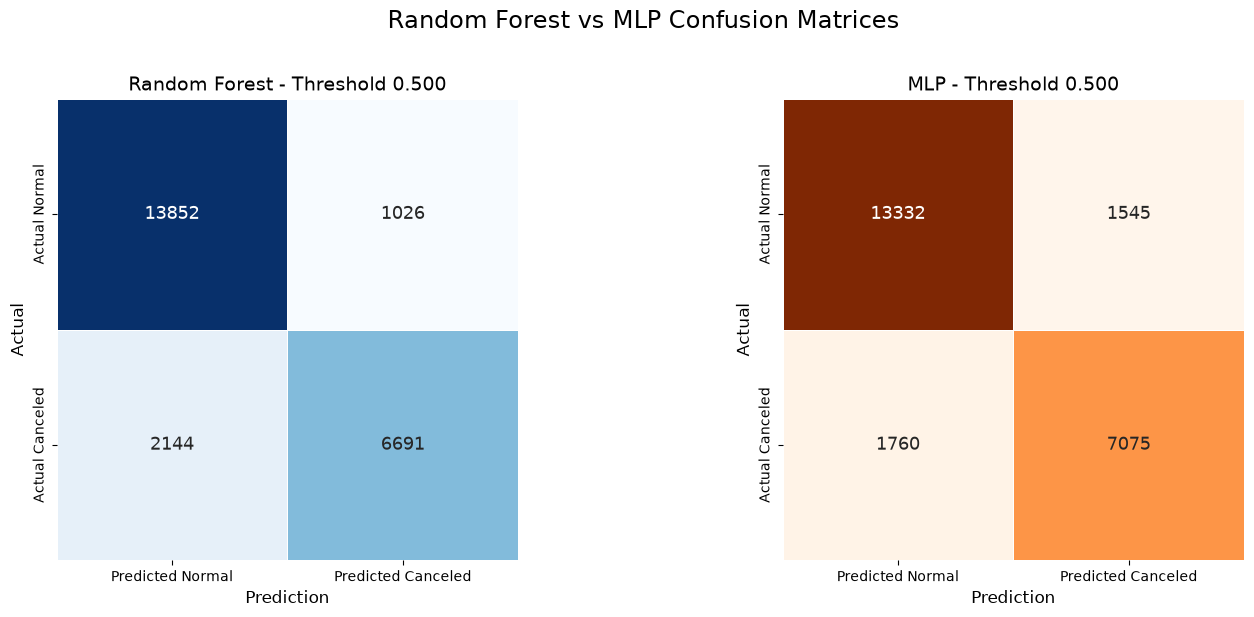

혼동행렬 저장 완료: model_dl/final/rf_mlp_confusion_matrices.png


In [6]:
# ── 원본 셀 64 | 과거 RF·MLP 혼동행렬 비교 ──
# 지표표의 tn/fp/fn/tp로 각 모델의 2×2 행렬을 재구성한다.
# 현재 입력 표에서는 RF·MLP 평가 예약 수가 다르다. 그대로 최종 공통 Test 비교로 사용하지 않는다.
# PNG를 저장하지만 모델 재학습은 하지 않는다.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest 기본 임계값 결과
rf_row = model_comparison[
    model_comparison["model"]
    == "Moderate Random Forest"
].iloc[0]

# MLP 기본 임계값 결과
mlp_row = model_comparison[
    model_comparison["model"]
    == "Final MLP"
].iloc[0]

# 혼동행렬 구성
rf_cm = np.array([
    [
        int(rf_row["tn"]),
        int(rf_row["fp"])
    ],
    [
        int(rf_row["fn"]),
        int(rf_row["tp"])
    ]
])

mlp_cm = np.array([
    [
        int(mlp_row["tn"]),
        int(mlp_row["fp"])
    ],
    [
        int(mlp_row["fn"]),
        int(mlp_row["tp"])
    ]
])

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

# Random Forest 혼동행렬
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    square=True,
    annot_kws={"size": 13},
    ax=axes[0]
)

axes[0].set_title(
    "Random Forest - Threshold 0.500",
    fontsize=14
)

axes[0].set_xlabel(
    "Prediction",
    fontsize=12
)

axes[0].set_ylabel(
    "Actual",
    fontsize=12
)

axes[0].set_xticklabels([
    "Predicted Normal",
    "Predicted Canceled"
])

axes[0].set_yticklabels(
    [
        "Actual Normal",
        "Actual Canceled"
    ],
    rotation=90,
    va="center"
)

# MLP 혼동행렬
sns.heatmap(
    mlp_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    linewidths=0.5,
    square=True,
    annot_kws={"size": 13},
    ax=axes[1]
)

axes[1].set_title(
    "MLP - Threshold 0.500",
    fontsize=14
)

axes[1].set_xlabel(
    "Prediction",
    fontsize=12
)

axes[1].set_ylabel(
    "Actual",
    fontsize=12
)

axes[1].set_xticklabels([
    "Predicted Normal",
    "Predicted Canceled"
])

axes[1].set_yticklabels(
    [
        "Actual Normal",
        "Actual Canceled"
    ],
    rotation=90,
    va="center"
)

fig.suptitle(
    "Random Forest vs MLP Confusion Matrices",
    fontsize=17,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "model_dl/final/rf_mlp_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "혼동행렬 저장 완료:",
    "model_dl/final/rf_mlp_confusion_matrices.png"
)

## 13. 확률 표시·기본 입력 트러블슈팅

Calibration Curve 진단, 같은 입력 비교, 학습 데이터와의 거리 확인을 포함한다. KNN 분류기 추가나 Platt Scaling 학습 단계가 아니다.


In [ ]:
# ── 원본 셀 65 | 트러블슈팅 영역 구분선 ──
# 실행 동작이 없는 주석 셀이다. 아래부터 확률 표시와 기본 입력 진단 과정이 이어진다.

# =============================

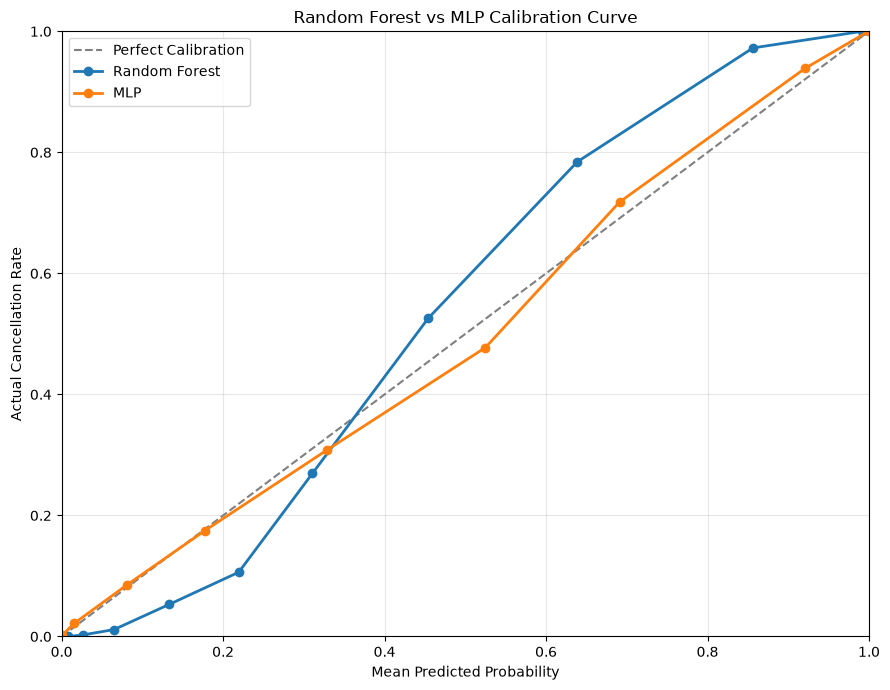

In [21]:
# ── 원본 셀 66 | 확률 신뢰도 진단: Calibration Curve ──
# 예측확률을 분위수 구간으로 묶어 구간 평균 확률(x축)과 실제 취소율(y축)을 비교한다.
# 대각선에 가까우면 해당 구간에서 확률 추정과 관측 비율이 비슷하다. 개별 예약의 확률이 정확하다는 보장은 아니다.
# 이 셀은 보정 상태를 그릴 뿐 Platt Scaling 같은 보정 모델을 학습하거나 확률을 수정하지 않는다.
# 주의: rf_test_probability와 mlp_test_probability 정의가 이 노트북 코드에 없다. 올바른 공통 Test 정답/확률을 먼저 준비해야 한다.
# 과거 RF 확률 진단은 공통 분할 최종 RF 평가와 다를 수 있으므로 기존 이미지를 최종 결과로 확정하지 않는다.

import matplotlib.pyplot as plt

from sklearn.calibration import (
    calibration_curve
)

# [해설] rf_test_probability의 생성 코드가 이 노트북에 없어 별도 준비가 필요하다.
rf_actual, rf_predicted = (
    calibration_curve(
        y_test,
        rf_test_probability,
        n_bins=10,
        # [해설] 예측확률 순서에 따른 분위수 구간이다. 동률이 많으면 구간 수/표본 수가 달라질 수 있다.
        strategy="quantile"
    )
)

mlp_actual, mlp_predicted = (
    calibration_curve(
        y_test,
        mlp_test_probability,
        n_bins=10,
        strategy="quantile"
    )
)

plt.figure(
    figsize=(9, 7)
)

# 완벽하게 보정된 기준선
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Perfect Calibration"
)

plt.plot(
    rf_predicted,
    rf_actual,
    marker="o",
    linewidth=2,
    label="Random Forest"
)

plt.plot(
    mlp_predicted,
    mlp_actual,
    marker="o",
    linewidth=2,
    label="MLP"
)

plt.title(
    "Random Forest vs MLP Calibration Curve"
)

plt.xlabel(
    "Mean Predicted Probability"
)

plt.ylabel(
    "Actual Cancellation Rate"
)

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "model_dl/final/"
    "rf_mlp_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [3]:
# ── 원본 셀 67 | 문제가 된 예전 Streamlit 기본 입력 재현 ──
# 각 범주 목록의 첫 항목과 고정 수치를 조합한다. 실제로 존재하는 예약 한 건을 가져오는 방식이 아니다.
# One-Hot 카테고리의 첫 값은 가장 흔한 값 또는 대표값을 의미하지 않는다.
# 주의: mlp_preprocessor는 이 셀보다 뒤의 모델 로드 셀에서 생성된다. 새 커널에서는 먼저 전처리기를 로드해야 한다.
# 이것은 진단용 예전 기본값이며, 이후 선택한 대표 기본 예약값으로 혼동하지 않는다.

import pandas as pd


categorical_cols = [
    "hotel",
    "arrival_date_month",
    "meal",
    "market_segment",
    "reserved_room_type",
    "customer_type",
    "country_group"
]


# 저장된 MLP 전처리기의 카테고리 확인
# [해설] mlp_preprocessor 객체는 먼저 저장 파일에서 로드되어 있어야 한다.
encoder = (
    mlp_preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
)


category_options = {
    column: list(categories)
    for column, categories in zip(
        categorical_cols,
        encoder.categories_
    )
}


# 현재 Streamlit 기본 입력 재현
streamlit_input = pd.DataFrame([{
    "hotel":
        category_options["hotel"][0],

    "arrival_date_month":
        category_options[
            "arrival_date_month"
        ][0],

    "meal":
        category_options["meal"][0],

    "market_segment":
        category_options[
            "market_segment"
        ][0],

    "reserved_room_type":
        category_options[
            "reserved_room_type"
        ][0],

    "customer_type":
        category_options[
            "customer_type"
        ][0],

    "country_group":
        category_options[
            "country_group"
        ][0],

    "lead_time": 30,
    "is_repeated_guest": 0,
    "previous_cancellations": 0,
    "previous_bookings_not_canceled": 0,
    "adr": 100.0,
    "required_car_parking_spaces": 0,
    "total_of_special_requests": 0,
    "has_agent": 0,
    "has_company": 0,
    "total_guests": 2,
    "total_nights": 2,
    "has_waiting_list": 0,
    "has_children": 0
}])


print(
    "Streamlit 기본 입력 생성 완료"
)

display(
    streamlit_input.T
)

Streamlit 기본 입력 생성 완료


,0
hotel,City Hotel
arrival_date_month,April
meal,BB
market_segment,Aviation
reserved_room_type,A
customer_type,Contract
country_group,BEL
lead_time,30
is_repeated_guest,0
previous_cancellations,0


In [23]:
# ── 원본 셀 68 | 공통 분할 데이터와 열 목록 저장 ──
# X_train/X_test와 내부 Sub-train/Validation을 정답·인덱스와 함께 joblib으로 저장한다.
# 현재 메모리의 분할을 그대로 저장하므로 잘못된 변수 상태에서 실행하면 공통 기준 파일을 덮어쓴다.
# 이 셀은 저장 코드이지 복원 코드가 아니다. 커널 재시작 후 데이터 복원은 joblib.load로 수행해야 한다.
# D:\pythonscript 경로는 사용자 PC 기준의 절대경로이다. 다른 환경에서 실행할 때 확인이 필요하다.

import joblib
from pathlib import Path

split_path = Path(
    r"D:\pythonscript\Deep_Learning_PRJ"
    r"\model_dl\comparison"
    r"\common_data_split.joblib"
)

split_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

# [해설] 현재 분할을 저장하는 쓰기 작업이다. 저장 파일에서 변수를 복원하지는 않는다.
joblib.dump(
    {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "X_subtrain": X_subtrain,
        "X_val": X_val,
        "y_subtrain": y_subtrain,
        "y_val": y_val,
        "categorical_cols": categorical_cols,
        "numeric_cols": numeric_cols
    },
    split_path,
    compress=3
)

print(
    "공통 분할 데이터 저장 완료:",
    split_path
)

공통 분할 데이터 저장 완료: D:\pythonscript\Deep_Learning_PRJ\model_dl\comparison\common_data_split.joblib


In [24]:
# ── 원본 셀 69 | 공통 RF·최종 MLP 로드 후 동일 입력 비교 ──
# 모델과 전처리기를 메모리에 없을 때만 불러온다. globals 검사 때문에 같은 이름의 오래된 객체가 있으면 그대로 사용될 수 있다.
# RF는 전처리 포함 파이프라인으로 원본 입력을 받고 MLP는 저장 전처리기로 transform한 배열을 받는다.
# [0, 1]은 RF의 두 번째 클래스 확률이다. 취소 클래스 1이 classes_[1]인지 확인하는 것이 안전하다.
# 학습은 하지 않으며 streamlit_input이 없으면 명시적으로 중단한다. compile=False는 추론만 할 때 사용한다.

import joblib
import pandas as pd
import tensorflow as tf


# 공통 분할 Random Forest가 메모리에 없으면 저장 파일에서 불러오기
# [해설] 존재 여부만 확인한다. 같은 이름의 오래된 객체인지 검증하는 코드는 아니다.
if "rf_common_model" not in globals():

    rf_common_model = joblib.load(
        "../ML_PRJ/"
        "model_dl/comparison/"
        "rf_common_split.joblib"
    )

    print(
        "저장된 공통 Random Forest를 불러왔습니다."
    )


# MLP 전처리기가 메모리에 없으면 불러오기
if "mlp_preprocessor" not in globals():

    mlp_preprocessor = joblib.load(
        "model_dl/final/"
        "final_mlp_preprocessor.joblib"
    )

    print(
        "저장된 MLP 전처리기를 불러왔습니다."
    )


# MLP 모델이 메모리에 없으면 불러오기
if "mlp_model" not in globals():

    mlp_model = tf.keras.models.load_model(
        "model_dl/final/"
        "final_mlp.keras",
        # [해설] 학습 재개가 아니라 추론 용도이므로 compile 복원을 생략한다.
        compile=False
    )

    print(
        "저장된 MLP 모델을 불러왔습니다."
    )


# Streamlit 기본 입력 존재 여부 확인
if "streamlit_input" not in globals():

    raise RuntimeError(
        "streamlit_input이 없습니다. "
        "기본 입력 생성 코드를 먼저 실행하세요."
    )


# 같은 원본 입력을 Random Forest에 입력
rf_common_input_probability = float(
    rf_common_model.predict_proba(
        streamlit_input
    )[0, 1]
)


# 같은 원본 입력을 MLP 전처리기로 변환
mlp_input_processed = (
    mlp_preprocessor
    .transform(
        streamlit_input
    )
    .astype("float32")
)


# 전처리된 입력을 MLP에 입력
mlp_input_probability = float(
    mlp_model.predict(
        mlp_input_processed,
        verbose=0
    ).ravel()[0]
)


# 결과 비교
common_input_comparison = pd.DataFrame([
    {
        "model":
            "Random Forest",

        "cancel_probability":
            rf_common_input_probability,

        "cancel_probability_percent":
            rf_common_input_probability
            * 100
    },
    {
        "model":
            "MLP",

        "cancel_probability":
            mlp_input_probability,

        "cancel_probability_percent":
            mlp_input_probability
            * 100
    }
])

display(
    common_input_comparison
)

print(
    "MLP 입력 크기:",
    mlp_input_processed.shape
)

,model,cancel_probability,cancel_probability_percent
0,Random Forest,0.080755,8.075484
1,MLP,0.000021,0.002060


MLP 입력 크기: (1, 64)


In [25]:
# ── 원본 셀 70 | 최근접 예약 검색으로 입력 진단 ──
# NearestNeighbors는 취소 예측용 KNN 분류 모델을 추가하는 것이 아니라 비슷한 입력 예약을 찾는 도구이다.
# fit은 검색 대상 X_train_processed를 등록하고 kneighbors는 거리와 행 위치를 반환한다.
# 스케일링·One-Hot 공간의 유클리드 거리이며 모델이 학습한 특성 중요도까지 반영한 거리는 아니다.
# 가까운 예약이라고 사업적으로 완전히 같은 조건인 것은 아니다.

from sklearn.neighbors import (
    NearestNeighbors
)

# MLP가 학습한 X_train을 동일하게 변환
X_train_processed = (
    mlp_preprocessor
    .transform(
        X_train
    )
    .astype("float32")
)

# Streamlit 입력은 이미 변환된 상태
query_processed = (
    mlp_input_processed
)

# 가장 유사한 예약 1,000건 탐색
neighbor_model = NearestNeighbors(
    n_neighbors=1000,
    metric="euclidean"
)

# [해설] 검색 대상 등록이다. is_canceled를 사용해 분류기를 학습하는 동작이 아니다.
neighbor_model.fit(
    X_train_processed
)

# [해설] distances는 거리, neighbor_positions는 X_train_processed 안의 행 위치이다.
distances, neighbor_positions = (
    neighbor_model.kneighbors(
        query_processed
    )
)

In [26]:
# ── 원본 셀 71 | 이웃 수에 따른 실제 취소율 확인 ──
# 50·100·300·500·1000개 이웃의 취소율과 거리를 비교한다. y_train의 0/1 평균이 취소 비율이다.
# neighbor_positions는 행 라벨이 아니라 위치이므로 iloc로 같은 위치의 정답을 가져온다.
# 이웃 취소율은 진단용 표본 통계이지 현재 입력의 참확률이나 MLP 보정 목표값이 아니다.
# 범주가 다른 예약이나 중복 예약이 많이 포함되면 취소율이 크게 바뀔 수 있다.

neighbor_summary = []

for neighbor_count in [
    50,
    100,
    300,
    500,
    1000
]:

    positions = (
        neighbor_positions[
            0,
            :neighbor_count
        ]
    )

    # [해설] iloc 위치 선택을 써 검색 배열과 정답 배열의 행을 맞춘다.
    neighbor_targets = (
        y_train.iloc[
            positions
        ]
    )

    neighbor_summary.append({
        "유사 예약 수":
            neighbor_count,

        "실제 취소 건수":
            int(
                neighbor_targets.sum()
            ),

        "실제 정상 건수":
            int(
                neighbor_count
                - neighbor_targets.sum()
            ),

        "실제 취소율":
            neighbor_targets.mean(),

        "실제 취소율(%)":
            neighbor_targets.mean()
            * 100,

        "평균 거리":
            distances[
                0,
                :neighbor_count
            ].mean(),

        "최대 거리":
            distances[
                0,
                :neighbor_count
            ].max()
    })


neighbor_summary = pd.DataFrame(
    neighbor_summary
)

display(
    neighbor_summary.round(6)
)

,유사 예약 수,실제 취소 건수,실제 정상 건수,실제 취소율,실제 취소율(%),평균 거리,최대 거리
0,50,42,8,0.840000,84.000000,2.456718,2.490410
1,100,55,45,0.550000,55.000000,2.546778,2.821501
2,300,154,146,0.513333,51.333333,2.752531,2.870827
3,500,224,276,0.448000,44.800000,2.806231,2.913914
4,1000,404,596,0.404000,40.400000,2.922701,3.181855


In [27]:
# ── 원본 셀 72 | 범주형 7개 조합의 학습 데이터 존재 여부 ──
# 각 행에서 7개 범주가 모두 같은지 all(axis=1)로 확인한다.
# 일치 건수가 0이면 그 범주 조합이 Train에 없었다는 뜻이다. 모델 오류나 전체 분포 밖 입력임을 단독으로 확정하는 검정은 아니다.
# 일치하는 행이 있으면 해당 행들의 실제 취소율도 참고로 출력한다.

categorical_match_mask = (
    X_train[categorical_cols]
    == streamlit_input.loc[
        0,
        categorical_cols
    ].to_numpy()
).all(
    axis=1
)

categorical_match_count = int(
    categorical_match_mask.sum()
)

print(
    "범주형 7개가 모두 같은 예약 수:",
    categorical_match_count
)

if categorical_match_count > 0:

    categorical_match_rate = (
        y_train.loc[
            categorical_match_mask
        ].mean()
    )

    print(
        "동일 범주 조합 실제 취소율:",
        f"{categorical_match_rate:.2%}"
    )

else:

    print(
        "동일 범주형 조합이 "
        "학습 데이터에 없습니다."
    )

범주형 7개가 모두 같은 예약 수: 0
동일 범주형 조합이 학습 데이터에 없습니다.


In [28]:
# ── 원본 셀 73 | 가까운 예약 20개의 조건·정답·두 모델 확률 ──
# 선택한 이웃들의 원래 특성, 실제 결과, RF·MLP 추정값을 함께 확인한다.
# 학습 데이터에 대한 예측이므로 이 표를 Test 성능이나 일반화 성능 평가로 사용하지 않는다.
# 거리 순으로 가깝더라도 국가·예약 경로 등 중요한 범주가 달라 확률은 크게 달라질 수 있다.

nearest_positions = (
    neighbor_positions[
        0,
        :20
    ]
)

nearest_rows = (
    X_train.iloc[
        nearest_positions
    ]
    .copy()
)

nearest_rows.insert(
    0,
    "distance",
    distances[
        0,
        :20
    ]
)

nearest_rows.insert(
    1,
    "actual_canceled",
    y_train.iloc[
        nearest_positions
    ].to_numpy()
)


# 가까운 예약에 대한 RF 확률
nearest_rows["rf_probability"] = (
    rf_common_model
    .predict_proba(
        X_train.iloc[
            nearest_positions
        ]
    )[:, 1]
)


# 가까운 예약에 대한 MLP 확률
nearest_processed = (
    mlp_preprocessor
    .transform(
        X_train.iloc[
            nearest_positions
        ]
    )
    .astype("float32")
)

nearest_rows["mlp_probability"] = (
    mlp_model.predict(
        nearest_processed,
        verbose=0
    ).ravel()
)


display(
    nearest_rows[
        [
            "distance",
            "actual_canceled",
            "rf_probability",
            "mlp_probability"
        ]
        + categorical_cols
        + [
            "lead_time",
            "adr",
            "total_nights",
            "total_guests",
            "previous_cancellations",
            "total_of_special_requests"
        ]
    ].round(6)
)

,distance,actual_canceled,rf_probability,mlp_probability,hotel,arrival_date_month,meal,market_segment,reserved_room_type,customer_type,country_group,lead_time,adr,total_nights,total_guests,previous_cancellations,total_of_special_requests
109830,2.110491,0,0.025139,0.000451,City Hotel,April,BB,Direct,A,Transient-Party,BEL,11,124.5,3,2,0,0
109829,2.110491,0,0.025139,0.000451,City Hotel,April,BB,Direct,A,Transient-Party,BEL,11,124.5,3,2,0,0
109731,2.385197,0,0.043009,0.002153,City Hotel,April,BB,Direct,A,Transient,BEL,8,148.0,4,2,0,0
109107,2.462949,0,0.182633,0.326982,City Hotel,April,BB,Direct,A,Transient,PRT,5,95.0,2,2,0,0
87216,2.465975,0,0.033870,0.008441,City Hotel,April,BB,Direct,A,Transient,Other,0,98.0,2,2,0,0
65530,2.468812,1,0.990231,0.998594,City Hotel,April,BB,Groups,A,Transient,PRT,54,110.0,2,2,0,0
65536,2.468812,1,0.990231,0.998594,City Hotel,April,BB,Groups,A,Transient,PRT,54,110.0,2,2,0,0
65545,2.468812,1,0.990231,0.998594,City Hotel,April,BB,Groups,A,Transient,PRT,54,110.0,2,2,0,0
65544,2.468812,1,0.990231,0.998594,City Hotel,April,BB,Groups,A,Transient,PRT,54,110.0,2,2,0,0
65527,2.468812,1,0.990231,0.998594,City Hotel,April,BB,Groups,A,Transient,PRT,54,110.0,2,2,0,0


In [29]:
# ── 원본 셀 74 | 기본 입력의 최근접 거리를 일반 예약과 비교 ──
# Train에서 최대 2,000개를 뽑아 두 이웃 중 두 번째 거리를 비교 대상으로 사용한다.
# 조회 대상 자신과의 0 거리를 피하려는 방식이며 중복 행이 있으면 두 번째 거리도 0일 수 있다.
# 현재 입력 거리를 중앙값·90/95/99% 분위와 비교한다. 이는 정식 OOD 판정 임계값이나 이상확률이 아니다.

rng = np.random.default_rng(
    42
)

sample_size = min(
    2000,
    len(X_train_processed)
)

# [해설] replace=False로 같은 위치를 두 번 뽑지 않는다.
sample_positions = rng.choice(
    len(X_train_processed),
    size=sample_size,
    replace=False
)

sample_distances, _ = (
    neighbor_model.kneighbors(
        X_train_processed[
            sample_positions
        ],
        n_neighbors=2
    )
)

# 첫 번째는 자기 자신이므로 두 번째 거리 사용
# [해설] 두 번째 이웃을 사용해 자기 자신을 제외하려 하지만 중복 예약의 0 거리는 남을 수 있다.
typical_nearest_distances = (
    sample_distances[:, 1]
)

print(
    "현재 입력의 가장 가까운 거리:",
    round(
        distances[0, 0],
        4
    )
)

print(
    "학습 데이터의 일반적인 최근접 거리"
)

print(
    "중앙값:",
    round(
        np.median(
            typical_nearest_distances
        ),
        4
    )
)

print(
    "90% 지점:",
    round(
        np.quantile(
            typical_nearest_distances,
            0.90
        ),
        4
    )
)

print(
    "95% 지점:",
    round(
        np.quantile(
            typical_nearest_distances,
            0.95
        ),
        4
    )
)

print(
    "99% 지점:",
    round(
        np.quantile(
            typical_nearest_distances,
            0.99
        ),
        4
    )
)

현재 입력의 가장 가까운 거리: 2.1105
학습 데이터의 일반적인 최근접 거리
중앙값: 0.2635
90% 지점: 1.4862
95% 지점: 1.7836
99% 지점: 2.2387


## 14. 실제 예약 기반 기본값 선정

최빈값·중앙값 프로필에 가까운 실제 학습 예약을 기본값 후보로 고른다. 추정확률을 임의로 올리는 보정이 아니다.


In [30]:
# ── 원본 셀 75 | 최빈값·중앙값으로 대표 프로필 생성 ──
# 범주형은 최빈값, 수치형은 중앙값을 조합해 학습 데이터 중심의 검색 기준을 만든다.
# 이 프로필 역시 실제 예약에 존재하지 않을 수 있으므로 곧바로 최종 기본값으로 확정하지 않는다.
# 다음 단계에서 이 프로필에 가까운 실제 Train 행을 선택한다.

import numpy as np
import pandas as pd

# 범주형 변수의 최빈값
categorical_modes = {
    column: X_train[column].mode().iloc[0]
    for column in categorical_cols
}

# 수치형 변수의 중앙값
numeric_medians = {
    column: X_train[column].median()
    for column in numeric_cols
}

# 대표 프로필 생성
# [해설] 실제 예약 한 건이 아니라 중심값을 조합한 검색 기준점이다.
representative_profile = pd.DataFrame([{
    **categorical_modes,
    **numeric_medians
}])

display(
    representative_profile.T
)

,0
hotel,City Hotel
arrival_date_month,August
meal,BB
market_segment,Online TA
reserved_room_type,A
customer_type,Transient
country_group,PRT
lead_time,70.0
is_repeated_guest,0.0
previous_cancellations,0.0


In [31]:
# ── 원본 셀 76 | 대표 프로필과 가까운 실제 예약 후보 검색 ──
# 이미 등록된 Train 검색 공간에서 프로필의 최근접 예약 20개를 찾는다.
# 프로필과 같은 최종 MLP 전처리기를 써 거리 공간을 맞춘다.
# 이 후보 탐색 자체는 정답이나 두 모델의 예측확률을 선택 기준으로 쓰지 않는다.

# 대표 프로필 전처리
representative_processed = (
    mlp_preprocessor
    .transform(
        representative_profile
    )
    .astype("float32")
)

# 이미 생성된 X_train_processed 사용
representative_distances, \
representative_positions = (
    neighbor_model.kneighbors(
        representative_processed,
        n_neighbors=20
    )
)

# 중복 조건을 확인할 후보 20개
candidate_positions = (
    representative_positions[0]
)

representative_candidates = (
    X_train.iloc[
        candidate_positions
    ]
    .copy()
)

representative_candidates.insert(
    0,
    "distance",
    representative_distances[0]
)

display(
    representative_candidates
)

,distance,hotel,arrival_date_month,meal,market_segment,reserved_room_type,customer_type,country_group,lead_time,is_repeated_guest,...,previous_bookings_not_canceled,adr,required_car_parking_spaces,total_of_special_requests,has_agent,has_company,total_guests,total_nights,has_waiting_list,has_children
72681,0.313777,City Hotel,August,BB,Online TA,A,Transient,PRT,69,0,...,0,80.10,0,0,1,0,2,3,0,0
56137,0.350004,City Hotel,August,BB,Online TA,A,Transient,PRT,53,0,...,0,109.80,0,0,1,0,2,3,0,0
41586,0.503435,City Hotel,August,BB,Online TA,A,Transient,PRT,104,0,...,0,76.50,0,0,1,0,2,3,0,0
41033,0.610136,City Hotel,August,BB,Online TA,A,Transient,PRT,97,0,...,0,76.50,0,0,1,0,2,2,0,0
41427,0.665280,City Hotel,August,BB,Online TA,A,Transient,PRT,0,0,...,0,90.00,0,0,1,0,2,3,0,0
41680,0.665280,City Hotel,August,BB,Online TA,A,Transient,PRT,0,0,...,0,90.00,0,0,1,0,2,3,0,0
40801,0.769371,City Hotel,August,BB,Online TA,A,Transient,PRT,0,0,...,0,98.00,0,0,1,0,2,2,0,0
41051,0.820843,City Hotel,August,BB,Online TA,A,Transient,PRT,147,0,...,0,76.50,0,0,1,0,2,3,0,0
73154,0.859403,City Hotel,August,BB,Online TA,A,Transient,PRT,36,0,...,0,100.00,0,0,1,0,2,1,0,0
42018,0.892195,City Hotel,August,BB,Online TA,A,Transient,PRT,149,0,...,0,80.75,0,0,1,0,2,4,0,0


In [32]:
# ── 원본 셀 77 | 가장 가까운 실제 예약을 대표 입력으로 선택 ──
# candidate_positions[0]의 실제 Train 행을 한 행 DataFrame으로 복사한다.
# 원본 인덱스와 실제 취소 여부를 출력하지만 정답을 조건으로 예약을 선택하지는 않는다.
# 대표는 학습 데이터 중심 프로필에 가깝다는 의미이며 운영 전체의 취소율을 대표한다는 뜻은 아니다.

representative_position = (
    candidate_positions[0]
)

# [해설] 이중 대괄호 위치 선택은 Series가 아닌 한 행 DataFrame 형태를 유지한다.
representative_input = (
    X_train.iloc[
        [representative_position]
    ]
    .copy()
)

representative_actual = int(
    y_train.iloc[
        representative_position
    ]
)

print(
    "대표 예약 원본 인덱스:",
    representative_input.index[0]
)

print(
    "대표 예약 실제 결과:",
    representative_actual
)

display(
    representative_input.T
)

대표 예약 원본 인덱스: 72681
대표 예약 실제 결과: 1


,72681
hotel,City Hotel
arrival_date_month,August
meal,BB
market_segment,Online TA
reserved_room_type,A
customer_type,Transient
country_group,PRT
lead_time,69
is_repeated_guest,0
previous_cancellations,0


In [33]:
# ── 원본 셀 78 | 대표 예약에서 RF·MLP 확률 재확인 ──
# 기본 입력을 실제 예약으로 바꾼 뒤 두 모델을 다시 예측한다. 모델 가중치나 확률 보정기를 바꾸지 않는다.
# 이전 실행의 RF 약 70.99%, MLP 약 76.12%는 해당 한 예약의 추정값이지 모델 전체 정확도가 아니다.
# 결과가 비슷해졌다고 모든 입력의 확률 신뢰도가 검증된 것은 아니다.

# Random Forest
representative_rf_probability = float(
    rf_common_model.predict_proba(
        representative_input
    )[0, 1]
)

# MLP
representative_mlp_processed = (
    mlp_preprocessor
    .transform(
        representative_input
    )
    .astype("float32")
)

representative_mlp_probability = float(
    mlp_model.predict(
        representative_mlp_processed,
        verbose=0
    ).ravel()[0]
)

representative_comparison = pd.DataFrame([
    {
        "model":
            "Random Forest",

        "cancel_probability":
            representative_rf_probability,

        "cancel_probability_percent":
            representative_rf_probability
            * 100
    },
    {
        "model":
            "MLP",

        "cancel_probability":
            representative_mlp_probability,

        "cancel_probability_percent":
            representative_mlp_probability
            * 100
    }
])

display(
    representative_comparison
)

,model,cancel_probability,cancel_probability_percent
0,Random Forest,0.709931,70.993071
1,MLP,0.761150,76.115042


In [34]:
# ── 원본 셀 79 | 대표 기본 입력 JSON 저장 ──
# 선택한 예약 한 행을 사전으로 바꾸고 NumPy 스칼라는 item()으로 Python 자료형으로 변환한다.
# streamlit_default_input.json에는 입력값만 저장하며 모델이나 예측확률을 저장하는 것이 아니다.
# JSON 저장만으로 Streamlit UI가 자동 변경되지는 않는다. 앱에서 읽거나 동일 값을 위젯 기본값에 반영해야 한다.
# 이 셀도 동일 파일을 덮어쓴다. 이번 주석본 생성 중에는 실행하지 않았다.

import json
from pathlib import Path

default_input_path = Path(
    "model_dl/final/"
    "streamlit_default_input.json"
)

default_input_data = (
    representative_input
    .iloc[0]
    .to_dict()
)

# NumPy 자료형을 JSON 저장 가능한 기본 자료형으로 변환
for key, value in default_input_data.items():

    # [해설] NumPy int64/float32 등의 스칼라를 JSON이 처리 가능한 Python 기본형으로 바꾼다.
    if hasattr(
        value,
        "item"
    ):
        default_input_data[key] = (
            value.item()
        )

with open(
    default_input_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        default_input_data,
        file,
        ensure_ascii=False,
        indent=2
    )

print(
    "Streamlit 대표 입력 저장 완료:",
    default_input_path
)

print(
    json.dumps(
        default_input_data,
        ensure_ascii=False,
        indent=2
    )
)

Streamlit 대표 입력 저장 완료: model_dl\final\streamlit_default_input.json
{
  "hotel": "City Hotel",
  "arrival_date_month": "August",
  "meal": "BB",
  "market_segment": "Online TA",
  "reserved_room_type": "A",
  "customer_type": "Transient",
  "country_group": "PRT",
  "lead_time": 69,
  "is_repeated_guest": 0,
  "previous_cancellations": 0,
  "previous_bookings_not_canceled": 0,
  "adr": 80.1,
  "required_car_parking_spaces": 0,
  "total_of_special_requests": 0,
  "has_agent": 1,
  "has_company": 0,
  "total_guests": 2,
  "total_nights": 3,
  "has_waiting_list": 0,
  "has_children": 0
}


In [ ]:
import pandas as pd

capture = pd.read_csv(
    "model_dl/comparison/capture_analysis/"
    "mlp_validation_capture.csv"
)

selected = capture.loc[
    capture["target_review_share"].round(2).isin([0.25, 0.50]),
    [
        "target_review_share",
        "expected_loss_threshold",
        "n_review",
        "canceled_amount_capture_rate"
    ]
]

print(selected.to_string(index=False))

출력값은 이렇게 연결돼.

행	사용할 경계
0.25의 expected_loss_threshold	HIGH 시작값 — q75
0.50의 expected_loss_threshold	MEDIUM 시작값 — q50

현재 결과는 상위 25%에서 금액의 74.00%, 상위 50%에서 95.89%를 포착하므로, 두 경계를 유지할 근거는 확보됐어. 다만 유일한 최적안이라는 뜻은 아니야. 예를 들어 상위 30% 관리도 80.44%를 포착하는 대안이야.

위 출력으로 정확한 경계값을 확인한 다음, 고정된 경계를 Test에 적용하자. 아직 서비스 등급은 바뀌지 않았어.

Q1. 출력된 두 경계값으로 LOW·MEDIUM·HIGH를 확정할까?

Q2. Te